In [ ]:
#Phenocopy analysis
#Step 1 Data Filtering
#Step 2 Data preparing
#Step 3 Plot and analysis
#########################

In [ ]:
# ── Step 1.1  Filter raw REF / ALT inputs against GTEx WGS V9 VCF ──
# Extracts VCF info (REF/ALT/AF) for each position via bcftools,
# maps back to input rows, and saves WGS-matched rows only.

import os, subprocess, tempfile
import pandas as pd
import numpy as np

# ── Paths ──────────────────────────────────────────────────
WORKDIR   = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
INPUT_DIR = "raw_inputs_2605"
VCF_PATH  = "/home/tx56/palmer_scratch/mpac_20250426/dbgap_wgs_copy/phg001796.v1.GTEx_v9_WGS_phased.genotype-calls-vcf.c1/GTEx_Analysis_2021-02-11_v9_WholeGenomeSeq_953Indiv.SHAPEIT2_phased.vcf.gz"

INPUTS = {
    "REF": (os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_refBg_050726.tsv"),
            os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_refBg_WGSonly.tsv")),
    "ALT": (os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_altBg_050726.tsv"),
            os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_altBg_WGSonly.tsv")),
}

os.chdir(WORKDIR)

def filter_wgs(in_file, out_file, vcf_path):
    df = pd.read_csv(in_file, sep='\t', low_memory=False)

    # Standardise chrom format for bcftools lookup
    df['_chr'] = df['chrom'].astype(str).apply(lambda x: x if x.startswith('chr') else 'chr' + x)
    df['_pos'] = df['pos'].astype(int)

    # Write unique positions to a temp file for bcftools -T
    unique_pos = df[['_chr', '_pos']].drop_duplicates()
    with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.txt') as tmp:
        unique_pos.to_csv(tmp, sep='\t', header=False, index=False)
        tmp_path = tmp.name

    # Query VCF: extract chrom, pos, ref, alt, and all sample genotypes
    cmd = ["bcftools", "query", "-T", tmp_path, "-f", "%CHROM\t%POS\t%REF\t%ALT[\t%GT]\n", vcf_path]
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, text=True, bufsize=1)

    vcf_data = {}
    for line in proc.stdout:
        parts = line.strip().split('\t')
        if len(parts) < 5: continue
        chrom = parts[0] if parts[0].startswith('chr') else 'chr' + parts[0]
        pos, ref, alt = int(parts[1]), parts[2], parts[3].split(',')[0]

        # Calculate ALT allele frequency across all samples
        alleles = [a for gt in parts[4:] for a in gt.replace('|', '/').split('/') if a != '.']
        af = alleles.count('1') / len(alleles) if alleles else np.nan
        vcf_data[(chrom, pos)] = (f"{ref}_{alt}", af)

    proc.wait()
    os.remove(tmp_path)

    # Map VCF results back to dataframe
    df['vcf_gt']     = df.apply(lambda r: vcf_data.get((r['_chr'], r['_pos']), (np.nan,))[0], axis=1)
    df['vcf_af']     = df.apply(lambda r: vcf_data.get((r['_chr'], r['_pos']), (None, np.nan))[1], axis=1)
    df['needs_flip'] = df['vcf_af'] > 0.5

    # Keep only rows found in WGS, drop internal lookup columns
    df_out = df.dropna(subset=['vcf_af']).drop(columns=['_chr', '_pos'])
    df_out.to_csv(out_file, sep='\t', index=False)

    leads = df_out[df_out['is_lead_variant'] == True]['lead_variant_id'].nunique()
    print(f"{in_file}: {len(df):,} → {len(df_out):,} retained | {leads} unique leads | {len(df)-len(df_out):,} dropped")

# ── Run for REF and ALT ────────────────────────────────────
for label, (in_f, out_f) in INPUTS.items():
    print(f"Processing {label}...")
    filter_wgs(in_f, out_f, VCF_PATH)

In [3]:
# ── Step 1.1-prepared  Load WGS-filtered files for downstream analysis ──

import os
import pandas as pd

# ── Paths ──────────────────────────────────────────────────
WORKDIR   = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
INPUT_DIR = "raw_inputs_2605"

REF_IN  = os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_refBg_050726.tsv")
ALT_IN  = os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_altBg_050726.tsv")
REF_WGS = os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_refBg_WGSonly.tsv")
ALT_WGS = os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_altBg_WGSonly.tsv")

os.chdir(WORKDIR)

# ── Load raw inputs and WGS-filtered files ─────────────────
df_ref_in  = pd.read_csv(REF_IN,  sep='\t', low_memory=False)
df_alt_in  = pd.read_csv(ALT_IN,  sep='\t', low_memory=False)
df_ref     = pd.read_csv(REF_WGS, sep='\t', low_memory=False)
df_alt     = pd.read_csv(ALT_WGS, sep='\t', low_memory=False)

# ── Summarise row and lead variant retention after WGS filter ──
for label, df_in, df_wgs in [("REF", df_ref_in, df_ref),
                              ("ALT", df_alt_in, df_alt)]:
    leads_in  = df_in ['lead_variant_id_gtex'].nunique()
    leads_out = df_wgs['lead_variant_id_gtex'].nunique()
    print(f"{'='*55}")
    print(f"[{label}]  Rows  : {len(df_in):>10,}  →  {len(df_wgs):>8,}  "
          f"({len(df_in) - len(df_wgs):>10,} dropped)")
    print(f"[{label}]  Unique lead_variant_id_gtex : "
          f"{leads_in:>4} in input  |  {leads_out:>4} kept  |  {leads_in - leads_out:>4} dropped")

# ── Preview WGS-annotated columns ─────────────────────────
for label, df in [("REF", df_ref), ("ALT", df_alt)]:
    print(f"{'='*55}")
    print(f"[{label}]  Shape : {df.shape}")
    print(f"[{label}]  Cols  : {df.columns.tolist()}")
    print(f"  vcf_gt     : {df['vcf_gt'].dtype}  | nulls: {df['vcf_gt'].isna().sum():,}")
    print(f"  vcf_af     : {df['vcf_af'].dtype}  | nulls: {df['vcf_af'].isna().sum():,}  "
          f"| min: {df['vcf_af'].min():.4f}  max: {df['vcf_af'].max():.4f}")
    print(f"  needs_flip : {df['needs_flip'].dtype}  "
          f"| True: {(df['needs_flip']==True).sum():,}  "
          f"| False: {(df['needs_flip']==False).sum():,}")
    display(df[['variant_id_gtex', 'lead_variant_id_gtex',
                'vcf_gt', 'vcf_af', 'needs_flip']].head(3))

print(f"{'='*55}")

[REF]  Rows  :  2,238,292  →    52,164  ( 2,186,128 dropped)
[REF]  Unique lead_variant_id_gtex :  576 in input  |   576 kept  |     0 dropped
[ALT]  Rows  :  2,297,908  →    54,656  ( 2,243,252 dropped)
[ALT]  Unique lead_variant_id_gtex :  580 in input  |   580 kept  |     0 dropped
[REF]  Shape : (52164, 25)
[REF]  Cols  : ['variant_id', 'variant_id_gtex', 'chrom', 'pos', 'ref', 'alt', 'skew_pred', 'abs_skew', 'cell_type', 'enhancer_ids', 'exceeds_lead_skew', 'is_lead_variant', 'lead_variant_id', 'lead_variant_id_gtex', 'lead_abs_skew', 'lead_pip', 'lead_tissue', 'lead_skew_sign', 'phenotype_id', 'gene_name', 'gene_short', 'in_seqlet', 'vcf_gt', 'vcf_af', 'needs_flip']
  vcf_gt     : object  | nulls: 0
  vcf_af     : float64  | nulls: 0  | min: 0.0005  max: 0.9995
  needs_flip : bool  | True: 3,596  | False: 48,568


,variant_id_gtex,lead_variant_id_gtex,vcf_gt,vcf_af,needs_flip
0,chr1_11986032_G_A_b38,chr1_11986032_G_A_b38,G_A,0.449108,False
1,chr1_11986032_G_T_b38,chr1_11986032_G_A_b38,G_A,0.449108,False
2,chr1_11986032_G_C_b38,chr1_11986032_G_A_b38,G_A,0.449108,False


[ALT]  Shape : (54656, 25)
[ALT]  Cols  : ['variant_id', 'variant_id_gtex', 'chrom', 'pos', 'ref', 'alt', 'skew_pred', 'abs_skew', 'cell_type', 'enhancer_ids', 'exceeds_lead_skew', 'is_lead_variant', 'lead_variant_id', 'lead_variant_id_gtex', 'lead_abs_skew', 'lead_pip', 'lead_tissue', 'lead_skew_sign', 'phenotype_id', 'gene_name', 'gene_short', 'in_seqlet', 'vcf_gt', 'vcf_af', 'needs_flip']
  vcf_gt     : object  | nulls: 0
  vcf_af     : float64  | nulls: 0  | min: 0.0005  max: 0.9995
  needs_flip : bool  | True: 4,209  | False: 50,447


,variant_id_gtex,lead_variant_id_gtex,vcf_gt,vcf_af,needs_flip
0,chr1_15245030_T_C_b38,chr1_15245030_T_C_b38,T_C,0.482162,False
1,chr1_15245017_A_T_b38,chr1_15245030_T_C_b38,A_G,0.001049,False
2,chr1_15245017_A_C_b38,chr1_15245030_T_C_b38,A_G,0.001049,False


In [5]:
# ── Step 1.2  Filter genotypes: match variant_id_gtex alleles against VCF ──
# Compares REF/ALT alleles in variant_id_gtex vs vcf_gt,
# keeps identical + flipped rows, drops true mismatches.
# Builds working_ref (clean leads) and working_alt (flip-intersect leads).

import os
import pandas as pd
import numpy as np

# ── Paths ──────────────────────────────────────────────────
WORKDIR   = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
INPUT_DIR = "raw_inputs_2605"

REF_WGS = os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_refBg_WGSonly.tsv")
ALT_WGS = os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_altBg_WGSonly.tsv")
REF_GT  = os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_refBg_WGSonly_GTChecked.tsv")
ALT_GT  = os.path.join(INPUT_DIR, "final_shadow_variant_dataset_605_altBg_WGSonly_GTChecked.tsv")

OUT_REF       = "working_ref.tsv"
OUT_ALT       = "working_alt.tsv"
OUT_FLIP_LIST = "ref_leadvar_flip_list.tsv"

os.chdir(WORKDIR)

# ── Step 1.2a  GT matching: compare variant_id_gtex alleles vs vcf_gt ─────
def check_gt_match(df):
    """Mark identical/flipped allele matches; drop true mismatches."""
    id_ref = df['variant_id_gtex'].str.split('_').str[2]   # REF from GTEx ID
    id_alt = df['variant_id_gtex'].str.split('_').str[3]   # ALT from GTEx ID
    v_ref  = df['vcf_gt'].str.split('_').str[0]            # REF from VCF
    v_alt  = df['vcf_gt'].str.split('_').str[1]            # ALT from VCF

    is_identical = (id_ref == v_ref) & (id_alt == v_alt)
    is_flipped   = (id_ref == v_alt) & (id_alt == v_ref)

    df_out = df[is_identical | is_flipped].copy()
    df_out['check_gt_match'] = is_identical[df_out.index]  # True=identical, False=flipped
    return df_out, is_identical.sum(), is_flipped.sum(), (~(is_identical | is_flipped)).sum()

for label, in_f, out_f in [("REF", REF_WGS, REF_GT),
                            ("ALT", ALT_WGS, ALT_GT)]:
    df = pd.read_csv(in_f, sep='\t', low_memory=False)
    df_out, n_identical, n_flipped, n_dropped = check_gt_match(df)
    df_out.to_csv(out_f, sep='\t', index=False)
    print(f"[{label}]  identical: {n_identical:,}  | flipped: {n_flipped:,}  | dropped: {n_dropped:,}  → saved: {out_f}")

# ── Step 1.2b  Load GT-checked files and summarise lead variants ───────────
df_ref_gt = pd.read_csv(REF_GT, sep='\t', low_memory=False)
df_alt_gt = pd.read_csv(ALT_GT, sep='\t', low_memory=False)

for label, df in [("REF", df_ref_gt), ("ALT", df_alt_gt)]:
    lead_rows  = df[df['variant_id_gtex'] == df['lead_variant_id_gtex']]
    flip_true  = lead_rows[lead_rows['needs_flip'] == True ]['lead_variant_id_gtex'].nunique()
    flip_false = lead_rows[lead_rows['needs_flip'] == False]['lead_variant_id_gtex'].nunique()
    print(f"{'='*55}")
    print(f"[{label}]  Rows: {len(df):>7,}  | Unique leads: {df['lead_variant_id_gtex'].nunique():>4}")
    print(f"[{label}]  Lead rows → needs_flip=False: {flip_false:>4}  | needs_flip=True: {flip_true:>4}")

# ── Step 1.2c  Compare no-flip leads across REF and ALT ───────────────────
def noflip_leads(df):
    return set(df[(df['variant_id_gtex'] == df['lead_variant_id_gtex']) &
                  (df['needs_flip'] == False)]['lead_variant_id_gtex'])

ref_noflip = noflip_leads(df_ref_gt)
alt_noflip = noflip_leads(df_alt_gt)

print(f"{'='*55}")
print(f"  REF needs_flip=False leads : {len(ref_noflip):>4}")
print(f"  ALT needs_flip=False leads : {len(alt_noflip):>4}")
print(f"  In BOTH (ALT ∩ REF)        : {len(alt_noflip & ref_noflip):>4}")
print(f"  ALT only                   : {len(alt_noflip - ref_noflip):>4}")
print(f"  REF only                   : {len(ref_noflip - alt_noflip):>4}")

# ── Step 1.2d  Build working_ref and working_alt ───────────────────────────
ref_lead_rows = df_ref_gt[df_ref_gt['variant_id_gtex'] == df_ref_gt['lead_variant_id_gtex']]
ref_clean_ids = set(ref_lead_rows[ref_lead_rows['needs_flip'] == False]['lead_variant_id_gtex'])
ref_flip_ids  = set(ref_lead_rows[ref_lead_rows['needs_flip'] == True ]['lead_variant_id_gtex'])

# working_ref: all rows belonging to clean (no-flip) lead signals
working_ref = df_ref_gt[df_ref_gt['lead_variant_id_gtex'].isin(ref_clean_ids)].copy()
working_ref.to_csv(OUT_REF, sep='\t', index=False)

# working_alt: ALT rows for signals where REF lead is flipped (intersect with ALT)
intersect_ids = ref_flip_ids & set(df_alt_gt['lead_variant_id_gtex'].unique())
working_alt   = df_alt_gt[df_alt_gt['lead_variant_id_gtex'].isin(intersect_ids)].copy()
working_alt.to_csv(OUT_ALT, sep='\t', index=False)

# Save flip lead variant list
with open(OUT_FLIP_LIST, 'w') as f:
    f.writelines(f"{v}\n" for v in sorted(intersect_ids))

print(f"{'='*55}")
print(f"  working_ref : {len(working_ref):>7,} rows | {working_ref['lead_variant_id_gtex'].nunique():>4} leads (needs_flip=False)")
print(f"  working_alt : {len(working_alt):>7,} rows | {working_alt['lead_variant_id_gtex'].nunique():>4} leads (flip ∩ ALT)")
print(f"  ref_flip_ids: {len(ref_flip_ids):>4}  | alt_available: {df_alt_gt['lead_variant_id_gtex'].nunique():>4}  | intersect: {len(intersect_ids):>4}")
print(f"  {OUT_FLIP_LIST} : {len(intersect_ids)} IDs written")
print(f"{'='*55}")

[REF]  identical: 16,829  | flipped: 0  | dropped: 35,335  → saved: raw_inputs_2605/final_shadow_variant_dataset_605_refBg_WGSonly_GTChecked.tsv
[ALT]  identical: 17,490  | flipped: 0  | dropped: 37,166  → saved: raw_inputs_2605/final_shadow_variant_dataset_605_altBg_WGSonly_GTChecked.tsv
[REF]  Rows:  16,829  | Unique leads:  576
[REF]  Lead rows → needs_flip=False:  419  | needs_flip=True:  149
[ALT]  Rows:  17,490  | Unique leads:  580
[ALT]  Lead rows → needs_flip=False:  426  | needs_flip=True:  146
  REF needs_flip=False leads :  419
  ALT needs_flip=False leads :  426
  In BOTH (ALT ∩ REF)        :  405
  ALT only                   :   21
  REF only                   :   14
  working_ref :  11,417 rows |  419 leads (needs_flip=False)
  working_alt :   5,136 rows |  143 leads (flip ∩ ALT)
  ref_flip_ids:  149  | alt_available:  580  | intersect:  143
  ref_leadvar_flip_list.tsv : 143 IDs written


In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pyarrow", "-q"], check=True)

CompletedProcess(args=['/home/tx56/.conda/envs/2407/bin/python', '-m', 'pip', 'install', 'pyarrow', '-q'], returncode=0)

In [2]:
# ── Step 1.3  Append GTEx v10 eQTL beta and classify lead variants ──
# Matches each lead variant × tissue × gene triplet to GTEx v10 signif_pairs,
# then classifies each lead as: concordant / discordant / no_pair.

import os
import pandas as pd
import numpy as np
import subprocess, sys

# ── Install parquet engine if missing ─────────────────────
subprocess.run([sys.executable, "-m", "pip", "install", "pyarrow", "-q"], check=True)

# ── Paths ──────────────────────────────────────────────────
WORKDIR   = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
EQTL_DIR  = "/home/tx56/palmer_scratch/mpac/dbgap_rna_seq/GTEx_Analysis_v10_eQTL"

REF_IN = "working_ref.tsv"
ALT_IN = "working_alt.tsv"

os.chdir(WORKDIR)

# ── Load working files ─────────────────────────────────────
df_ref = pd.read_csv(REF_IN, sep='\t', low_memory=False)
df_alt = pd.read_csv(ALT_IN, sep='\t', low_memory=False)

for label, df in [("REF", df_ref), ("ALT", df_alt)]:
    print(f"[{label}]  Rows: {len(df):>7,}  | Leads: {df['lead_variant_id_gtex'].nunique():>4}  | Tissues: {df['lead_tissue'].nunique():>3}")

# ── Helper: sign of a numeric value ───────────────────────
def sgn(x):
    x = float(x) if not pd.isna(x) else np.nan
    return 0 if pd.isna(x) else (1 if x > 0 else -1 if x < 0 else 0)

# ── Step 1.3a  Append lead eQTL beta from GTEx v10 signif_pairs ───────────
def append_lead_eqtl_beta(df):
    """Per tissue, merge GTEx v10 slope onto lead variant × gene pairs."""
    out = []
    df = df.copy()
    df["phenotype_id_base"] = df["phenotype_id"].str.split('.').str[0]

    for tissue in df["lead_tissue"].dropna().unique():
        pq  = os.path.join(EQTL_DIR, f"{tissue}.v10.eQTLs.signif_pairs.parquet")
        sub = df[df["lead_tissue"] == tissue].copy()
        if not os.path.exists(pq):
            sub["lead_eqtl_beta"] = np.nan
            out.append(sub)
            continue
        eqtl = (pd.read_parquet(pq, columns=["variant_id", "gene_id", "slope"])
                  .assign(phenotype_id_base=lambda d: d["gene_id"].str.split('.').str[0])
                  .rename(columns={"variant_id": "lead_variant_id_gtex", "slope": "lead_eqtl_beta"})
                  [["lead_variant_id_gtex", "phenotype_id_base", "lead_eqtl_beta"]])
        sub = sub.merge(eqtl, on=["lead_variant_id_gtex", "phenotype_id_base"], how="left")
        out.append(sub)

    return pd.concat(out, ignore_index=True).drop(columns=["phenotype_id_base"])

df_ref_eqtl = append_lead_eqtl_beta(df_ref)
df_alt_eqtl = append_lead_eqtl_beta(df_alt)

for label, df in [("REF", df_ref_eqtl), ("ALT", df_alt_eqtl)]:
    print(f"[{label}]  Rows: {len(df):>7,}  | eqtl_beta found: {df['lead_eqtl_beta'].notna().sum():>6,}  | null: {df['lead_eqtl_beta'].isna().sum():>6,}")

# ── Step 1.3b  Classify leads: concordant / discordant / no_pair ───────────
def build_lead_summary(df):
    """Aggregate triplets per lead variant and assign concordance class."""
    t = (df[['lead_variant_id_gtex', 'lead_tissue', 'phenotype_id',
             'lead_skew_sign', 'lead_eqtl_beta', 'gene_name']]
           .drop_duplicates()
           .copy())

    t["phenotype_id_base"] = t["phenotype_id"].astype(str).str.split('.').str[0]
    t = t.drop_duplicates(subset=['lead_variant_id_gtex', 'lead_tissue', 'phenotype_id_base'])

    t["lead_skew_sign"] = pd.to_numeric(t["lead_skew_sign"], errors="coerce")
    t["lead_eqtl_beta"] = pd.to_numeric(t["lead_eqtl_beta"], errors="coerce")
    t["eqtl_sign"]      = t["lead_eqtl_beta"].apply(sgn)
    t["pair_present"]   = t["eqtl_sign"] != 0
    t["concordant_row"] = t["pair_present"] & (t["lead_skew_sign"].apply(sgn) == t["eqtl_sign"])

    agg = t.groupby("lead_variant_id_gtex").agg(
        all_pairs_present = ("pair_present",      "all"),
        any_concordant    = ("concordant_row",     "any"),
        n_triplets        = ("phenotype_id_base",  "size"),
        n_pairs_nonnull   = ("lead_eqtl_beta",     lambda s: s.notna().sum()),
    ).reset_index()

    # Attach metadata (tissue, gene) for each lead
    meta = (t.sort_values("lead_variant_id_gtex")
             .drop_duplicates("lead_variant_id_gtex")
             [["lead_variant_id_gtex", "phenotype_id", "lead_tissue", "gene_name"]])
    agg = agg.merge(meta, on="lead_variant_id_gtex", how="left")

    agg["lead_class"] = np.where(~agg["all_pairs_present"], "no_pair",
                         np.where( agg["any_concordant"],   "concordant", "discordant"))
    return agg

ref_lead_sum = build_lead_summary(df_ref_eqtl)
alt_lead_sum = build_lead_summary(df_alt_eqtl)

for label, ls in [("REF", ref_lead_sum), ("ALT", alt_lead_sum)]:
    vc = ls["lead_class"].value_counts()
    print(f"{'='*55}")
    print(f"[{label}]  Total leads : {len(ls):>4}")
    print(f"[{label}]  concordant  : {vc.get('concordant', 0):>4}")
    print(f"[{label}]  discordant  : {vc.get('discordant', 0):>4}")
    print(f"[{label}]  no_pair     : {vc.get('no_pair',    0):>4}")

print(f"{'='*55}")

[REF]  Rows:  11,417  | Leads:  419  | Tissues:  50
[ALT]  Rows:   5,136  | Leads:  143  | Tissues:  49
[REF]  Rows:  11,417  | eqtl_beta found: 11,334  | null:     83
[ALT]  Rows:   5,136  | eqtl_beta found:  5,072  | null:     64
[REF]  Total leads :  419
[REF]  concordant  :  296
[REF]  discordant  :  116
[REF]  no_pair     :    7
[ALT]  Total leads :  143
[ALT]  concordant  :   36
[ALT]  discordant  :  100
[ALT]  no_pair     :    7


In [5]:
# ── Step 1.4  Filter leads, build combined match input, and tag variants ──
# REF keeps concordant leads; ALT keeps discordant leads.
# Tags each variant as: lead / rare (AF<1% & skew>lead_skew) / control.
# Combines both into match_input_all.tsv for downstream window matching.

import os
import pandas as pd
import numpy as np

# ── Paths ──────────────────────────────────────────────────
WORKDIR = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"

REF_OUT      = "working_refBg_eqtl_filtered.tsv"
ALT_OUT      = "working_altBg_eqtl_filtered.tsv"
REF_DROP_CSV = "working_refBg_dropped_leads.csv"
ALT_DROP_CSV = "working_altBg_dropped_leads.csv"
COMBINED_OUT = "match_input_all.tsv"

os.chdir(WORKDIR)

# ── Step 1.4a  Filter rows: REF keeps concordant, ALT keeps discordant ─────
filtered = {}

for label, df_eqtl, lead_sum, keep_class, out_tsv, drop_csv in [
    ("REF", df_ref_eqtl, ref_lead_sum, "concordant", REF_OUT, REF_DROP_CSV),
    ("ALT", df_alt_eqtl, alt_lead_sum, "discordant", ALT_OUT, ALT_DROP_CSV),
]:
    ls = lead_sum.copy()
    ls["kept"] = ls["lead_class"] == keep_class
    keep_leads = set(ls.loc[ls["kept"], "lead_variant_id_gtex"])

    opposite = "discordant" if keep_class == "concordant" else "concordant"
    ls["drop_reason"] = np.where(ls["kept"], "",
                         np.where(ls["lead_class"] == "no_pair",
                                  "no_pair_in_gtex_signif_pairs",
                                  f"{opposite}_pred_vs_eqtl"))

    out     = df_eqtl[df_eqtl["lead_variant_id_gtex"].isin(keep_leads)].copy()
    dropped = ls[~ls["kept"]].copy()

    out.to_csv(out_tsv,   sep='\t', index=False)
    dropped.to_csv(drop_csv, index=False)
    filtered[label] = out

    print(f"{'='*55}")
    print(f"[{label}]  keep_mode     : {keep_class}")
    print(f"[{label}]  Input  rows   : {len(df_eqtl):>7,}")
    print(f"[{label}]  Kept   leads  : {len(keep_leads):>4}  →  {len(out):>7,} rows")
    print(f"[{label}]  Dropped leads : {len(dropped):>4}")
    for reason, cnt in dropped["drop_reason"].value_counts().items():
        print(f"    {reason:<45}: {cnt:>4}")

print(f"{'='*55}")

# ── Step 1.4b  Assign variant_tag: lead / rare / control ───────────────────
def assign_variant_tag(df):
    df = df.copy()
    df['vcf_af']       = pd.to_numeric(df['vcf_af'],       errors='coerce')
    df['abs_skew']     = pd.to_numeric(df['abs_skew'],     errors='coerce')
    df['lead_abs_skew']= pd.to_numeric(df['lead_abs_skew'],errors='coerce')

    conditions = [
        df['is_lead_variant'] == True,
        (df['vcf_af'] < 0.01) & (df['abs_skew'] > df['lead_abs_skew']),
    ]
    df['variant_tag'] = np.select(conditions, ['lead', 'rare'], default='control')
    return df

for label in ["REF", "ALT"]:
    filtered[label] = assign_variant_tag(filtered[label])

# ── Step 1.4c  Report variant tag counts per background ────────────────────
for label, prefix in [("REF", "refbg"), ("ALT", "altbg")]:
    df = filtered[label]
    tag_counts   = df.groupby('variant_tag')['variant_id'].nunique()
    obs_rare     = df[df['vcf_af'] < 0.01]['variant_id'].nunique()
    total_leads  = df[df['is_lead_variant'] == True]['lead_variant_id_gtex'].nunique()
    linked_leads = df[df['variant_tag'] == 'rare']['lead_variant_id_gtex'].nunique()

    print(f"\n{'='*75}")
    print(f"  [{label}]")
    print(f"{'='*75}")
    print(f"  {'Total Unique Variants':<50} | {df['variant_id'].nunique():>10,}")
    print(f"  {'Observed Rare (AF < 1%)':<50} | {obs_rare:>10,}")
    print(f"  {'Predicted Rare (tag=rare)':<50} | {tag_counts.get('rare',    0):>10,}")
    print(f"  {'Control (tag=control)':<50} | {tag_counts.get('control', 0):>10,}")
    print(f"  {'-'*62}")
    print(f"  {'Unique Lead Variants (tag=lead)':<50} | {total_leads:>10,}")
    print(f"  {'Lead Variants linked to Predicted Rare':<50} | {linked_leads:>10,}")

    # Save tagged files
    df.to_csv(f"{prefix}_tagged_full.tsv", sep='\t', index=False)
    df[df['vcf_af'] < 0.01].to_csv(f"{prefix}_observed_rare.csv", index=False)
    df[df['variant_tag'] == 'rare'].to_csv(f"{prefix}_predicted_rare.csv", index=False)
    print(f"  Saved → {prefix}_tagged_full.tsv / _observed_rare.csv / _predicted_rare.csv")

print(f"{'='*75}")

# ── Step 1.4d  Combine REF + ALT and save match input ──────────────────────
ref = filtered["REF"].copy(); ref["pred_bg"] = "ref"
alt = filtered["ALT"].copy(); alt["pred_bg"] = "alt"
combined = pd.concat([ref, alt], ignore_index=True)
combined.to_csv(COMBINED_OUT, sep='\t', index=False)

print(f"\n  ref rows : {len(ref):>7,}")
print(f"  alt rows : {len(alt):>7,}")
print(f"  combined : {len(combined):>7,}  | cols: {combined.shape[1]}")

# ── Counts by variant_tag × pred_bg ───────────────────────
print("\n--- Unique variants by variant_tag × pred_bg ---")
ct = combined.groupby(['pred_bg', 'variant_tag'])['variant_id'].nunique().unstack(fill_value=0)
ct['TOTAL'] = ct.sum(axis=1)
print(ct.to_string())

# ── Counts by lead_tissue × variant_tag (top 15 tissues) ──
print("\n--- Unique variants by lead_tissue × variant_tag (top 15 tissues) ---")
tissue_ct = (combined.groupby(['lead_tissue', 'variant_tag'])['variant_id']
                      .nunique().unstack(fill_value=0))
tissue_ct['TOTAL'] = tissue_ct.sum(axis=1)
print(tissue_ct.sort_values('TOTAL', ascending=False).head(15).to_string())

print(f"\n  Saved → {COMBINED_OUT}")

[REF]  keep_mode     : concordant
[REF]  Input  rows   :  11,417
[REF]  Kept   leads  :  296  →    8,546 rows
[REF]  Dropped leads :  123
    discordant_pred_vs_eqtl                      :  116
    no_pair_in_gtex_signif_pairs                 :    7
[ALT]  keep_mode     : discordant
[ALT]  Input  rows   :   5,136
[ALT]  Kept   leads  :  100  →    3,805 rows
[ALT]  Dropped leads :   43
    concordant_pred_vs_eqtl                      :   36
    no_pair_in_gtex_signif_pairs                 :    7

  [REF]
  Total Unique Variants                              |      1,955
  Observed Rare (AF < 1%)                            |      1,315
  Predicted Rare (tag=rare)                          |         35
  Control (tag=control)                              |      1,628
  --------------------------------------------------------------
  Unique Lead Variants (tag=lead)                    |        296
  Lead Variants linked to Predicted Rare             |         35
  Saved → refbg_tagged_full.ts

In [ ]:
################################
#Step 2 Data preparing##########
################################

In [8]:
# ── Step 2.0  Build GTEx sample linker ──
# Maps GTEx sample IDs → subject IDs → tissue names (meta_tissue),
# matched against GCT header to confirm real RNA-seq samples only.

import os
import gzip
import pandas as pd

# ── Paths ──────────────────────────────────────────────────
WORKDIR     = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
MPAC_DIR    = "/home/tx56/palmer_scratch/mpac_20250426"
SAMPLE_ATTR = os.path.join(MPAC_DIR, "GTEx_Analysis_v10_Annotations_SampleAttributesDS.txt")
TPM_GCT     = os.path.join(MPAC_DIR, "dbgap_rna_seq/GTEx_Analysis_v10_RNASeQCv2.4.2_gene_tpm.gct.gz")
OUT_TSV     = "gtex_sample_linker.tsv"

os.chdir(WORKDIR)

# ── 1. Load sample attributes (keep RNA-seq samples only: contain -SM-) ──────
attr = pd.read_csv(SAMPLE_ATTR, sep='\t', usecols=['SAMPID', 'SMTSD'], low_memory=False)
attr = attr[attr['SAMPID'].str.contains('-SM-', na=False)].copy()
attr.columns = ['sample_id', 'smtsd']
attr['subject'] = attr['sample_id'].apply(lambda x: '-'.join(x.split('-')[:2]))

# ── 2. Confirm samples exist in GCT header ────────────────
print("Reading GCT header...")
with gzip.open(TPM_GCT, 'rt') as f:
    next(f); next(f)
    gct_samples = set(next(f).strip().split('\t')[2:])   # skip Name, Description cols
print(f"  GCT samples              : {len(gct_samples):,}")

attr = attr[attr['sample_id'].isin(gct_samples)].copy()
print(f"  Attr rows matched to GCT : {len(attr):,}")
print(f"  Unique subjects          : {attr['subject'].nunique():,}")
print(f"  Unique SMTSD tissues     : {attr['smtsd'].nunique():,}")

# ── 3. Build meta_tissue name to match lead_tissue column convention ──────────
# e.g. 'Adipose - Subcutaneous' → 'Adipose_Subcutaneous'
def smtsd_to_meta(s):
    return (s.replace(' - ', '_').replace(' (', '_')
             .replace(')', '').replace(' ', '_'))

attr['meta_tissue'] = attr['smtsd'].apply(smtsd_to_meta)

# ── 4. Save linker and build in-memory lookup dicts ───────
attr = attr[['subject', 'meta_tissue', 'smtsd', 'sample_id']]
attr.to_csv(OUT_TSV, sep='\t', index=False)

# (subject, meta_tissue) → sample_id  [used in Step 2.1 TPM lookup]
linker = {(r['subject'], r['meta_tissue']): r['sample_id'] for _, r in attr.iterrows()}

print(f"\n  Linker saved → {OUT_TSV}")
print(f"  Linker keys (subject × tissue) : {len(linker):,}")
print(attr.head(5).to_string(index=False))

Reading GCT header...
  GCT samples              : 19,616
  Attr rows matched to GCT : 19,616
  Unique subjects          : 946
  Unique SMTSD tissues     : 54

  Linker saved → gtex_sample_linker.tsv
  Linker keys (subject × tissue) : 19,616
   subject                          meta_tissue                                    smtsd                     sample_id
GTEX-1117F                          Whole_Blood                              Whole Blood      GTEX-1117F-0005-SM-HL9SH
GTEX-1117F             Brain_Frontal_Cortex_BA9             Brain - Frontal Cortex (BA9) GTEX-1117F-0011-R10b-SM-GI4VE
GTEX-1117F          Brain_Cerebellar_Hemisphere            Brain - Cerebellar Hemisphere GTEX-1117F-0011-R11b-SM-GIN8R
GTEX-1117F               Brain_Substantia_nigra                 Brain - Substantia nigra  GTEX-1117F-0011-R2b-SM-GI4VL
GTEX-1117F Brain_Anterior_cingulate_cortex_BA24 Brain - Anterior cingulate cortex (BA24)  GTEX-1117F-0011-R3a-SM-GJ3PJ


In [9]:
# ── Step 2.1  Extract per-individual genotype + TPM ──
# For each variant in match_input_all.tsv:
#   1. Query VCF with bcftools for exact REF/ALT match at chrom:pos
#   2. Normalize genotype (handle strand flips)
#   3. Look up per-subject TPM from GTEx v10 GCT for the matched gene × tissue
# Output: variant_complete_tpm.csv — one row per variant × subject

import os, gzip, subprocess, shutil
import pandas as pd
from collections import defaultdict

# ── Paths ──────────────────────────────────────────────────
WORKDIR    = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
MPAC_DIR   = "/home/tx56/palmer_scratch/mpac_20250426"
META_IN    = "match_input_all.tsv"
LINKER_TSV = "gtex_sample_linker.tsv"
TPM_GCT    = os.path.join(MPAC_DIR, "dbgap_rna_seq/GTEx_Analysis_v10_RNASeQCv2.4.2_gene_tpm.gct.gz")
VCF_PATH   = os.path.join(MPAC_DIR, "dbgap_wgs_copy/phg001796.v1.GTEx_v9_WGS_phased.genotype-calls-vcf.c1/"
                                     "GTEx_Analysis_2021-02-11_v9_WholeGenomeSeq_953Indiv.SHAPEIT2_phased.vcf.gz")
OUT_CSV    = "variant_complete_tpm.csv"

os.chdir(WORKDIR)

# ── Resolve bcftools ───────────────────────────────────────
HOME     = os.path.expanduser("~")
bcftools = os.path.join(HOME, ".conda/envs/2407/bin/bcftools")
if not os.path.isfile(bcftools):
    bcftools = shutil.which('bcftools') or (_ for _ in ()).throw(EnvironmentError("bcftools not found"))
print(f"  bcftools : {bcftools}")

# ── 1. Load metadata ───────────────────────────────────────
# Deduplicate to unique variant × tissue × gene rows for VCF querying
df = pd.read_csv(META_IN, sep='\t', low_memory=False)
df['gene_short'] = df['phenotype_id'].astype(str).str.split('.').str[0]
KEY_COLS = ['variant_id_gtex', 'lead_variant_id_gtex', 'lead_tissue', 'cell_type', 'variant_tag', 'gene_short']
df_sub = df[KEY_COLS].drop_duplicates().copy()
print(f"  Metadata rows                   : {len(df):,}")
print(f"  Unique variant-window-gene rows : {len(df_sub):,}")

# ── 2. Load linker ─────────────────────────────────────────
# (subject, meta_tissue) → sample_id mapping
lnk    = pd.read_csv(LINKER_TSV, sep='\t', low_memory=False)
linker = {(r['subject'], r['meta_tissue']): r['sample_id'] for _, r in lnk.iterrows()}
print(f"  Linker keys : {len(linker):,}  | Subjects: {lnk['subject'].nunique():,}  | Tissues: {lnk['meta_tissue'].nunique():,}")

# ── 3. Stream TPM GCT ──────────────────────────────────────
# Stream line-by-line to avoid loading the full matrix into memory
# Only retain genes and samples relevant to our variant set
print("\nStreaming TPM GCT...")
target_genes   = set(df_sub['gene_short'].unique())
target_samples = set(lnk['sample_id'].unique())
tpm_lookup     = {}   # (gene_base, sample_id) → tpm float

with gzip.open(TPM_GCT, 'rt') as f:
    next(f); next(f)
    header        = next(f).strip().split('\t')
    col_idx       = [i for i, s in enumerate(header) if s in target_samples]
    idx_to_sample = {i: header[i] for i in col_idx}
    print(f"  GCT columns matched : {len(col_idx):,}")
    for line in f:
        parts = line.rstrip('\n').split('\t')
        gene  = parts[0].split('.')[0]
        if gene not in target_genes:
            continue
        for i in col_idx:
            tpm_lookup[(gene, idx_to_sample[i])] = float(parts[i])

print(f"  TPM entries loaded  : {len(tpm_lookup):,}")

# ── 4. Get VCF subject list ────────────────────────────────
# Extract subject IDs (GTEX-XXXXX) from full sample IDs in VCF header
vcf_samples = subprocess.run([bcftools, 'query', '-l', VCF_PATH],
                              capture_output=True, text=True).stdout.strip().split('\n')
subjects = ['-'.join(s.split('-')[:2]) for s in vcf_samples]
print(f"  VCF subjects : {len(subjects):,}")

# ── 5. GT normalisation helpers ────────────────────────────
def normalize_gt(gt_raw, is_flipped):
    """Sort allele indices; invert if variant is strand-flipped vs metadata."""
    gt_str = gt_raw.replace('|', '/')
    if '.' in gt_str:
        return None
    try:
        a1, a2 = [int(x) for x in gt_str.split('/')]
    except ValueError:
        return 'other'
    if is_flipped:      # swap ref/alt encoding when strand is flipped
        a1, a2 = 1 - a1, 1 - a2
    return '/'.join(str(x) for x in sorted([a1, a2]))

GT_CLASS = {'0/0': 'CC', '0/1': 'CT', '1/1': 'TT'}

# ── 6. Query VCF per unique chrom:pos ──────────────────────
# Group variants by position to minimise bcftools calls (one call per position)
# Match REF/ALT exactly; attempt reverse match for strand flips
print("\nQuerying VCF...")
vid_to_rows = defaultdict(list)
for _, row in df_sub.iterrows():
    vid_to_rows[row['variant_id_gtex']].append(row)

pos_to_vids = defaultdict(list)
for vid in vid_to_rows:
    p = vid.split('_')
    if len(p) >= 5:
        pos_to_vids[(p[0], p[1])].append(vid)

print(f"  Unique chrom:pos positions : {len(pos_to_vids):,}")

output_data    = []
matched_count  = 0
unmatched_vids = []

for (chrom, pos), vids_at_pos in pos_to_vids.items():
    result = subprocess.run(
        [bcftools, 'query', '-r', f"{chrom}:{pos}-{pos}",
         '-f', '%CHROM\t%POS\t%REF\t%ALT[\t%GT]\n', VCF_PATH],
        capture_output=True, text=True
    )
    if result.returncode != 0 or not result.stdout.strip():
        for vid in vids_at_pos:
            unmatched_vids.append((vid, 'not_in_vcf'))
        continue

    # Build (ref, alt) → genotype list from all VCF lines at this position
    vcf_records = {}
    for line in result.stdout.strip().split('\n'):
        parts = line.strip().split('\t')
        if len(parts) < 5 or parts[1] != pos:
            continue
        vcf_records[(parts[2], parts[3].split(',')[0])] = parts[4:]

    for vid in vids_at_pos:
        p = vid.split('_')
        meta_ref, meta_alt = p[2], p[3]

        # Forward match; fall back to reverse (strand flip)
        if   (meta_ref, meta_alt) in vcf_records: gts, is_flipped = vcf_records[(meta_ref, meta_alt)], False
        elif (meta_alt, meta_ref) in vcf_records: gts, is_flipped = vcf_records[(meta_alt, meta_ref)], True;  print(f"  [FLIPPED] {vid}")
        else: unmatched_vids.append((vid, f"no_ref_alt_match:{list(vcf_records.keys())}")); continue

        # Emit one row per subject
        for row in vid_to_rows[vid]:
            for i, gt_raw in enumerate(gts):
                gt_str = normalize_gt(gt_raw, is_flipped)
                if not gt_str or gt_str == 'other':
                    continue
                subj      = subjects[i]
                sample_id = linker.get((subj, row['lead_tissue']))
                tpm_val   = tpm_lookup.get((row['gene_short'], sample_id), pd.NA) if sample_id else pd.NA
                output_data.append([
                    vid, row['lead_variant_id_gtex'], row['lead_tissue'],
                    row['cell_type'], row['variant_tag'], subj, row['gene_short'],
                    gt_str, GT_CLASS.get(gt_str, 'other'), tpm_val
                ])
        matched_count += 1

    if matched_count % 500 == 0 and matched_count > 0:
        print(f"  Matched {matched_count:,} / {len(vid_to_rows):,} variants...")

# ── 7. Save output ─────────────────────────────────────────
out_df = pd.DataFrame(output_data, columns=[
    'variant_id', 'lead_variant_id_gtex', 'tissue',
    'cell_type', 'variant_tag', 'subject', 'gene',
    'genotype', 'gt_class', 'tpm'
])
out_df.to_csv(OUT_CSV, index=False)

print(f"\n{'='*55}")
print(f"  Saved           : {OUT_CSV}")
print(f"  Total rows      : {len(out_df):,}")
print(f"  Unique subjects : {out_df['subject'].nunique():,}")
print(f"  Unique tissues  : {out_df['tissue'].nunique():,}")
print(f"  TPM present     : {out_df['tpm'].notna().sum():,}")
print(f"  TPM missing     : {out_df['tpm'].isna().sum():,}")
print(f"  Variants matched   : {matched_count:,}  | unmatched: {len(unmatched_vids):,}")
print(f"\n  Genotype distribution:")
print(out_df['genotype'].value_counts().to_string())
print(f"\n  gt_class distribution:")
print(out_df['gt_class'].value_counts().to_string())
print(f"{'='*55}")

  bcftools : /home/tx56/.conda/envs/2407/bin/bcftools
  Metadata rows                   : 12,351
  Unique variant-window-gene rows : 12,351
  Linker keys : 19,616  | Subjects: 946  | Tissues: 54

Streaming TPM GCT...
  GCT columns matched : 19,616
  TPM entries loaded  : 8,258,336
  VCF subjects : 953

Querying VCF...
  Unique chrom:pos positions : 2,622
  Matched 500 / 2,622 variants...
  Matched 1,000 / 2,622 variants...
  Matched 1,500 / 2,622 variants...
  Matched 2,000 / 2,622 variants...
  Matched 2,500 / 2,622 variants...

  Saved           : variant_complete_tpm.csv
  Total rows      : 11,769,500
  Unique subjects : 953
  Unique tissues  : 50
  TPM present     : 6,509,132
  TPM missing     : 5,260,368
  Variants matched   : 2,622  | unmatched: 0

  Genotype distribution:
genotype
0/0    10283129
0/1      900776
1/1      585595

  gt_class distribution:
gt_class
CC    10283129
CT      900776
TT      585595


In [10]:
# ── Step 3.0  Load TPM, transform, compute exclusive Z-scores, save ──
# For each lead-variant window:
#   - minor_dosage recodes genotype so 2 = hom-minor (after strand flip if needed)
#   - Subjects hom-minor at the lead variant are excluded entirely
#   - Baseline: minor_dosage==0 at lead AND no rare/control mutations in window
#   - Subjects carrying exactly ONE tag group (lead/rare/control) get a Z-score
#   - Subjects carrying mutations in >1 group (mixed) are excluded from output
#   - Z-score = (log2(1+TPM) - baseline_mean) / baseline_sd

import os
import pandas as pd
import numpy as np

# ── Paths ──────────────────────────────────────────────────
WORKDIR  = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
META_IN  = "match_input_all.tsv"
TPM_IN   = "variant_complete_tpm.csv"
OUT_Z    = "individual_variant_zscores_exclusive_log2.csv"

os.chdir(WORKDIR)

# ── 1. Load metadata (variant-level flags) ────────────────
df_meta = pd.read_csv(META_IN, sep='\t', low_memory=False)
df_meta['is_af_rare'] = np.where(df_meta['vcf_af'] <= 0.5,
                                  df_meta['vcf_af'], 1 - df_meta['vcf_af']) < 0.01
META_COLS = ['variant_id_gtex', 'lead_variant_id_gtex', 'lead_tissue',
             'cell_type', 'variant_tag', 'is_af_rare', 'needs_flip', 'pred_bg']
df_meta = df_meta[META_COLS].drop_duplicates()
print(f"  Metadata rows : {len(df_meta):,}  | variant_tag: {df_meta['variant_tag'].value_counts().to_dict()}")

# ── 2. Load TPM, drop missing, apply log2(1+TPM) ─────────
df = pd.read_csv(TPM_IN, low_memory=False)
df['tpm'] = pd.to_numeric(df['tpm'], errors='coerce')
n_before = len(df)
df = df.dropna(subset=['tpm'])
print(f"  TPM rows: {n_before:,} → {len(df):,} after dropping nulls ({n_before - len(df):,} dropped)")

df['tpm_log2'] = np.log2(1 + df['tpm'])
print(f"  log2(1+TPM) — mean: {df['tpm_log2'].mean():.3f}  median: {df['tpm_log2'].median():.3f}  skew: {df['tpm_log2'].skew():.3f}")

# ── 3. Attach metadata flags (needs_flip, is_af_rare, pred_bg) ───────────────
df = df.rename(columns={'variant_id': 'variant_id_gtex'})
df = df.merge(
    df_meta[['variant_id_gtex', 'needs_flip', 'is_af_rare', 'pred_bg']].drop_duplicates(),
    on='variant_id_gtex', how='left'
)

# ── 4. Genotype → dosage; recode to minor_dosage via flip ─
# minor_dosage: 0 = hom-major, 1 = het, 2 = hom-minor
# needs_flip=True → 2 - dosage_orig inverts the allele axis
gt_map = {'0/0': 0, '0|0': 0,
          '0/1': 1, '1/0': 1, '0|1': 1, '1|0': 1,
          '1/1': 2, '1|1': 2}
df['dosage_orig']  = df['genotype'].map(gt_map)
df['minor_dosage'] = np.where(df['needs_flip'] == True,
                               2 - df['dosage_orig'], df['dosage_orig'])
print(f"  Unmapped genotypes : {df['dosage_orig'].isna().sum():,}")

# ── 5. Compute exclusive Z-scores per window ──────────────
# Windows defined by: lead_variant × tissue × cell_type × pred_bg
print("\nComputing Z-scores...")
results       = []
skipped_small = 0
total_windows = 0

for (l_id, tissue, ct, p_bg), win in df.groupby(
        ['lead_variant_id_gtex', 'tissue', 'cell_type', 'pred_bg'], sort=False):
    total_windows += 1
    win = win.copy()

    # Pivot: subject × variant_id_gtex → minor_dosage
    pivot = win.pivot_table(index='subject', columns='variant_id_gtex',
                            values='minor_dosage', aggfunc='max')
    tpm_map = win.drop_duplicates('subject').set_index('subject')['tpm_log2'].to_dict()

    rare_vids = [v for v in win.loc[win['variant_tag'] == 'rare',    'variant_id_gtex'].unique() if v != l_id]
    ctrl_vids = [v for v in win.loc[win['variant_tag'] == 'control', 'variant_id_gtex'].unique() if v != l_id]

    # Classify each subject
    base_vals, subj_groups = [], {}
    for subj, dos in pivot.iterrows():
        # Exclude subjects hom-minor at lead (minor_dosage==2)
        if dos.get(l_id, 0) == 2:
            continue
        has_lead = dos.get(l_id, 0) == 1
        has_rare = any(dos.get(v, 0) >= 1 for v in rare_vids)
        has_ctrl = any(dos.get(v, 0) >= 1 for v in ctrl_vids)
        n_groups = int(has_lead) + int(has_rare) + int(has_ctrl)

        if n_groups == 0:
            subj_groups[subj] = 'baseline'
            if subj in tpm_map:
                base_vals.append(tpm_map[subj])
        elif n_groups == 1:
            subj_groups[subj] = 'lead' if has_lead else ('rare' if has_rare else 'control')
        # n_groups > 1 → mixed: excluded from output, NOT from baseline

    if len(base_vals) < 10:       # skip underpowered windows
        skipped_small += 1
        continue

    mu = np.mean(base_vals)
    sd = max(np.std(base_vals), 1e-6)

    # Emit one row per subject × variant carrying the mutation
    for subj, group in subj_groups.items():
        if group in ('baseline', 'mixed') or subj not in tpm_map:
            continue
        z   = (tpm_map[subj] - mu) / sd
        dos = pivot.loc[subj]

        if group == 'lead':
            results.append([l_id, subj, tissue, ct, l_id, 'lead', False, z, p_bg])
        else:
            vids = rare_vids if group == 'rare' else ctrl_vids
            for vid in vids:
                if dos.get(vid, 0) >= 1:
                    is_r = bool(win.loc[win['variant_id_gtex'] == vid, 'is_af_rare'].iloc[0])
                    results.append([vid, subj, tissue, ct, l_id, group, is_r, z, p_bg])

    if total_windows % 100 == 0:
        print(f"  {total_windows:,} windows | {len(results):,} results so far...")

# ── 6. Save ────────────────────────────────────────────────
df_z = pd.DataFrame(results, columns=[
    'variant_id', 'subject', 'tissue', 'cell_type',
    'lead_variant', 'variant_tag', 'is_af_rare', 'z_score', 'pred_bg'
])
df_z.to_csv(OUT_Z, index=False)

# ── 7. Summary ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Saved  : {OUT_Z}")
print(f"  Rows   : {len(df_z):,}  | Windows: {total_windows:,}  | Skipped (<10 baseline): {skipped_small:,}")

print(f"\n  Row counts by variant_tag × pred_bg:")
ct_tbl = df_z.groupby(['pred_bg', 'variant_tag']).size().unstack(fill_value=0)
ct_tbl['TOTAL'] = ct_tbl.sum(axis=1)
print(ct_tbl.to_string())

print(f"\n  Z-score summary by variant_tag:")
print(df_z.groupby('variant_tag')['z_score'].describe().round(3).to_string())
print(f"{'='*60}")

  Metadata rows : 12,351  | variant_tag: {'control': 10285, 'lead': 1892, 'rare': 174}
  TPM rows: 11,769,500 → 6,509,132 after dropping nulls (5,260,368 dropped)
  log2(1+TPM) — mean: 2.534  median: 2.115  skew: 1.078
  Unmapped genotypes : 0

Computing Z-scores...
  100 windows | 23,181 results so far...
  200 windows | 45,545 results so far...
  300 windows | 50,146 results so far...
  400 windows | 70,975 results so far...
  500 windows | 92,058 results so far...
  600 windows | 109,813 results so far...
  700 windows | 133,919 results so far...
  900 windows | 176,240 results so far...
  1,000 windows | 194,078 results so far...
  1,100 windows | 210,895 results so far...
  1,200 windows | 227,200 results so far...
  1,300 windows | 245,505 results so far...
  1,400 windows | 267,345 results so far...
  1,500 windows | 284,371 results so far...
  1,600 windows | 299,863 results so far...
  1,700 windows | 324,503 results so far...
  1,800 windows | 344,197 results so far...

  Sav

In [ ]:
################################
#Step 3 Plot and analysis#######
################################

  indiv : 361,496 rows  | tags: {'lead': 240653, 'control': 120657, 'rare': 186}
  meta  : 12,351 rows

  High-skew control windows to drop : 42
  [RARE]  before: 76  after: 75  dropped: 1  phenocopying: 23
  [CTRL]  before: 1,538  after: 1,503  dropped: 35  phenocopying: 229


/tmp/ipykernel_3455119/1668969261.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


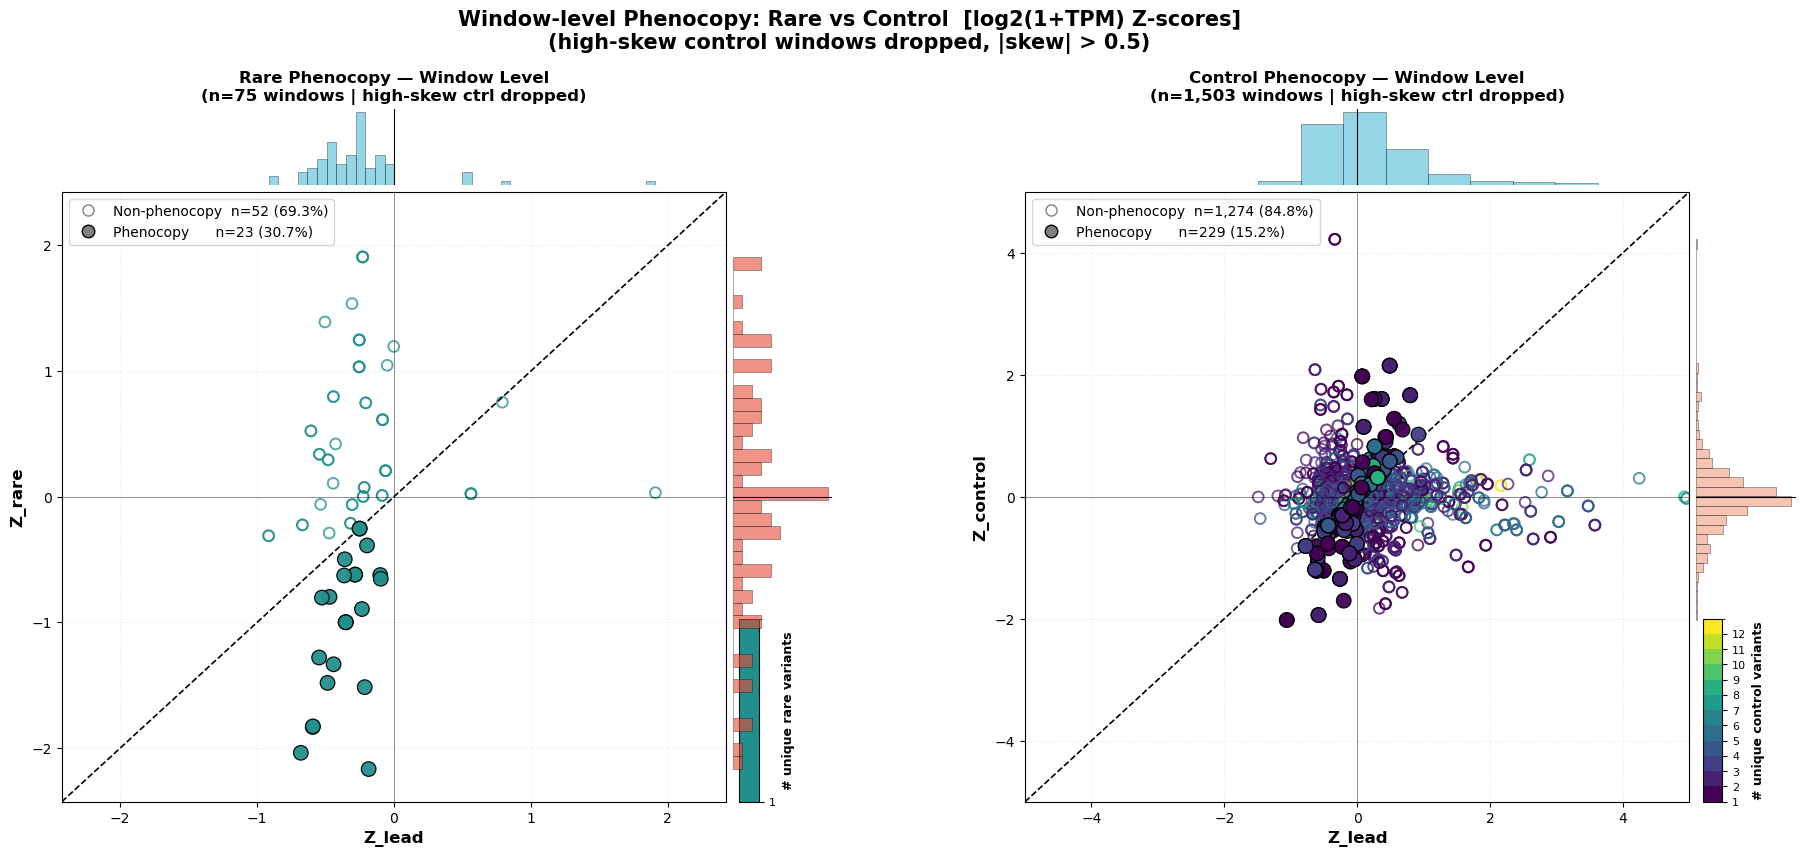

In [11]:
# ── Step 3.1  Load z-scores, drop high-skew control windows, plot phenocopy ──
# Loads individual z-scores + metadata, drops windows where any control
# variant has abs_skew > 0.5, then plots window-level rare vs control phenocopy.

%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

# ── Paths ──────────────────────────────────────────────────
WORKDIR    = "/home/tx56/palmer_scratch/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
INDIV_FILE = "individual_variant_zscores_exclusive_log2.csv"
MATCH_FILE = "match_input_all.tsv"

os.chdir(WORKDIR)

# ── Colors ─────────────────────────────────────────────────
C_LEAD, C_RARE, C_CTRL, C_BLUE = '#4DBBD5', '#E64B35', '#F39B7F', '#4DBBD5'

# ── Window key columns ─────────────────────────────────────
WIN = ['lead_variant_id_gtex', 'lead_tissue', 'cell_type']

# ── 1. Load files ──────────────────────────────────────────
indiv = pd.read_csv(INDIV_FILE, low_memory=False)
indiv = indiv.rename(columns={'subject': 'sample_name', 'z_score': 'zscore',
                               'lead_variant': 'lead_variant_id_gtex',
                               'tissue': 'lead_tissue'})
indiv['variant_tag'] = indiv['variant_tag'].str.lower().str.strip()
indiv['zscore']      = pd.to_numeric(indiv['zscore'], errors='coerce')

meta = pd.read_csv(MATCH_FILE, sep='\t', low_memory=False)
meta['variant_tag'] = meta['variant_tag'].str.lower().str.strip()
meta['abs_skew']    = pd.to_numeric(meta['abs_skew'], errors='coerce')

print(f"  indiv : {len(indiv):,} rows  | tags: {indiv['variant_tag'].value_counts().to_dict()}")
print(f"  meta  : {len(meta):,} rows")

# ── 2. Identify high-skew control windows (abs_skew > 0.5) ───────────────────
# Any window containing a control variant with |skew| > 0.5 is dropped entirely
hs_windows = (meta[(meta['variant_tag'] == 'control') & (meta['abs_skew'] > 0.5)]
              [WIN].drop_duplicates())
print(f"\n  High-skew control windows to drop : {len(hs_windows):,}")

# ── 3. Build window-level z-score summaries ───────────────
# Z per window = mean of per-subject mean z-scores
def window_z(tag, col):
    """Mean z-score per window for a given tag."""
    return (indiv[indiv['variant_tag'] == tag]
            .groupby(WIN + ['sample_name'])['zscore'].mean().reset_index()
            .groupby(WIN)['zscore'].mean().reset_index(name=col))

def window_n(tag, col):
    """Unique variant count per window for a given tag."""
    return (indiv[indiv['variant_tag'] == tag]
            [WIN + ['variant_id']].drop_duplicates()
            .groupby(WIN)['variant_id'].nunique().reset_index(name=col))

def is_phenocopy(z_lead, z_var):
    if pd.isna(z_lead) or pd.isna(z_var): return False
    return (z_lead > 0 and z_var > z_lead) or (z_lead < 0 and z_var < z_lead)

z_lead = window_z('lead', 'Z_lead')

def build_window_df(tag, z_col):
    """Inner-join lead × tag windows, attach z-scores, flag phenocopy."""
    lead_w = indiv[indiv['variant_tag'] == 'lead'][WIN].drop_duplicates()
    tag_w  = indiv[indiv['variant_tag'] == tag ][WIN].drop_duplicates()
    win    = lead_w.merge(tag_w, on=WIN, how='inner')
    return (win
            .merge(window_z(tag, z_col), on=WIN, how='inner')
            .merge(z_lead,              on=WIN, how='inner')
            .merge(window_n(tag, 'n_vars'), on=WIN, how='left')
            .assign(is_phenocopying=lambda d: d.apply(
                lambda r: is_phenocopy(r['Z_lead'], r[z_col]), axis=1)))

df_rare_base = build_window_df('rare',    'Z_rare')
df_ctrl_base = build_window_df('control', 'Z_control')

# ── 4. Anti-join: drop high-skew windows ──────────────────
def antijoin(df):
    m = df.merge(hs_windows, on=WIN, how='left', indicator=True)
    return m[m['_merge'] == 'left_only'].drop(columns='_merge').copy()

df_rare = antijoin(df_rare_base)
df_ctrl = antijoin(df_ctrl_base)

for label, base, filt in [("RARE", df_rare_base, df_rare),
                           ("CTRL", df_ctrl_base, df_ctrl)]:
    print(f"  [{label}]  before: {len(base):,}  after: {len(filt):,}  "
          f"dropped: {len(base)-len(filt):,}  "
          f"phenocopying: {filt['is_phenocopying'].sum():,}")

# ── 5. Plot ────────────────────────────────────────────────
def scatter_panel(ax, ax_top, df, z_col, title, ylabel, dot_color, cb_label, lim):
    cmap = plt.cm.viridis
    vmin, vmax = int(df['n_vars'].min()), int(df['n_vars'].max())
    norm = matplotlib.colors.BoundaryNorm(np.arange(vmin, vmax + 2), cmap.N)

    df_n = df[~df['is_phenocopying']]
    df_p = df[ df['is_phenocopying']]

    # Non-phenocopy: open circles
    for _, r in df_n.iterrows():
        ax.scatter(r['Z_lead'], r[z_col], facecolors='none',
                   edgecolors=[cmap(norm(r['n_vars']))],
                   s=60, lw=1.4, alpha=0.75, zorder=2)
    # Phenocopy: filled circles with black edge
    if not df_p.empty:
        ax.scatter(df_p['Z_lead'], df_p[z_col],
                   c=df_p['n_vars'], cmap=cmap, norm=norm,
                   edgecolors='black', s=110, lw=0.9, alpha=0.95, zorder=4)

    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1.2, zorder=3)
    ax.axhline(0, color='k', lw=0.6, alpha=0.5)
    ax.axvline(0, color='k', lw=0.6, alpha=0.5)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim),
           xlabel='Z_lead', ylabel=ylabel)
    ax.xaxis.label.set(fontweight='bold', fontsize=12)
    ax.yaxis.label.set(fontweight='bold', fontsize=12)
    ax.grid(True, ls=':', alpha=0.25)

    # Colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cb = plt.colorbar(sm, cax=ax.inset_axes([1.02, 0.0, 0.03, 0.30]))
    cb.set_label(cb_label, fontsize=9, fontweight='bold')
    cb.set_ticks(np.arange(vmin, vmax + 1))
    cb.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
    cb.ax.tick_params(labelsize=8)

    total = len(df)
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='none',
               markeredgecolor='grey', markersize=8, lw=1.4,
               label=f"Non-phenocopy  n={len(df_n):,} ({len(df_n)/total*100:.1f}%)"),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
               markeredgecolor='black', markersize=9,
               label=f"Phenocopy      n={len(df_p):,} ({len(df_p)/total*100:.1f}%)"),
    ], fontsize=10, framealpha=0.8, loc='upper left')

    # Top histogram (Z_lead distribution)
    ax_top.hist(df['Z_lead'], bins=40, color=C_BLUE, alpha=0.6, edgecolor='black', lw=0.4)
    ax_top.axvline(0, color='k', lw=0.8)
    ax_top.set_xlim(-lim, lim); ax_top.axis('off')
    ax_top.set_title(f"{title}\n(n={total:,} windows | high-skew ctrl dropped)",
                     fontsize=12, fontweight='bold', pad=6)

    # Right histogram (Z_var distribution)
    rax = ax.inset_axes([1.01, 0, 0.15, 1], sharey=ax)
    rax.hist(df[z_col], orientation='horizontal', bins=40,
             color=dot_color, alpha=0.6, edgecolor='black', lw=0.4)
    rax.axhline(0, color='k', lw=0.8); rax.axis('off')

lim_rare = min(max(df_rare['Z_lead'].abs().max(), df_rare['Z_rare'].abs().max()) * 1.12, 20)

fig   = plt.figure(figsize=(21, 9))
outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.45)

def make_axes(cell):
    gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=cell,
                                          height_ratios=[1, 8], hspace=0.02)
    return fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

ax_top_l, ax_l = make_axes(outer[0, 0])
ax_top_r, ax_r = make_axes(outer[0, 1])

scatter_panel(ax_l, ax_top_l, df_rare, 'Z_rare',
              "Rare Phenocopy — Window Level", "Z_rare",
              C_RARE, "# unique rare variants", lim_rare)

scatter_panel(ax_r, ax_top_r, df_ctrl, 'Z_control',
              "Control Phenocopy — Window Level", "Z_control",
              C_CTRL, "# unique control variants", 5)

plt.suptitle("Window-level Phenocopy: Rare vs Control  [log2(1+TPM) Z-scores]\n"
             "(high-skew control windows dropped, |skew| > 0.5)",
             fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
# plt.savefig("phenocopy_window_level.pdf", bbox_inches='tight', dpi=300)
plt.show()

# ── In memory after this cell ──────────────────────────────
# df_rare / df_ctrl      : filtered window dfs (post high-skew drop)
# df_rare_base / df_ctrl_base : pre-drop baselines
# hs_windows             : dropped windows
# is_phenocopy()         : helper function
# WIN                    : window key columns

In [12]:
# ── Step 3.2  Export phenocopy rare windows + Fisher's exact test ──
# Pulls all variant × window rows for phenocopy rare windows,
# assigns Z to the correct tag column (others NA), previews and tests.

import os
import numpy as np
import pandas as pd
import scipy.stats as stats

# ── 1. Identify phenocopy rare windows from step 3.1 ──────
rare_pheno_wins = (df_rare[df_rare['is_phenocopying']][WIN]
                   .drop_duplicates().reset_index(drop=True))
print(f"  Phenocopy rare windows : {len(rare_pheno_wins):,}")

# ── 2. Pull all individual rows for those windows ─────────
pheno_indiv = (indiv[indiv['variant_tag'].isin(['lead', 'rare', 'control'])]
               .merge(rare_pheno_wins, on=WIN, how='inner'))

# ── 3. Mean z-score per variant × window × tag ────────────
var_z = (pheno_indiv
         .groupby(WIN + ['variant_id', 'variant_tag'])['zscore']
         .mean().reset_index(name='z_val'))

# ── 4. Assign Z to correct column, NA elsewhere ───────────
for tag, col in [('lead', 'Z_lead'), ('rare', 'Z_rare'), ('control', 'Z_control')]:
    var_z[col] = np.where(var_z['variant_tag'] == tag, var_z['z_val'], np.nan)

# ── 5. Final columns, dedup, sort, round ──────────────────
out_df = (var_z
          .drop(columns='z_val')
          [['variant_id', 'lead_variant_id_gtex', 'lead_tissue', 'cell_type',
            'variant_tag', 'Z_lead', 'Z_rare', 'Z_control']]
          .drop_duplicates(subset=['variant_id', 'lead_variant_id_gtex', 'lead_tissue', 'cell_type'])
          .sort_values(['lead_variant_id_gtex', 'lead_tissue', 'cell_type', 'variant_tag', 'variant_id'])
          .reset_index(drop=True))

for col in ['Z_lead', 'Z_rare', 'Z_control']:
    out_df[col] = pd.to_numeric(out_df[col], errors='coerce').round(4)

# ── 6. Summary + preview ──────────────────────────────────
print(f"\n  Total rows : {len(out_df):,}  | Windows: {out_df[WIN].drop_duplicates().__len__():,}")
for tag in ['lead', 'rare', 'control']:
    print(f"    {tag:<8} : {(out_df['variant_tag'] == tag).sum():,}")
print(f"\n  Preview (n=10):")
print(out_df.head(10).to_string(index=False))

# os.makedirs('gtex_results', exist_ok=True)
# out_df.to_csv('gtex_results/phenocopy_rare_windows.csv', index=False)

# ── 7. Fisher's exact: rare vs control phenocopy rate ─────
# All counts derived live from df_rare / df_ctrl (step 3.1)
n_rare_win  = len(df_rare);  n_rare_pheno = int(df_rare['is_phenocopying'].sum())
n_ctrl_win  = len(df_ctrl);  n_ctrl_pheno = int(df_ctrl['is_phenocopying'].sum())
n_rare_non  = n_rare_win - n_rare_pheno
n_ctrl_non  = n_ctrl_win - n_ctrl_pheno

odds_ratio, p_val = stats.fisher_exact(
    [[n_rare_pheno, n_rare_non],
     [n_ctrl_pheno, n_ctrl_non]],
    alternative='greater'
)

print(f"\n{'='*60}")
print(f"  WINDOW-LEVEL: Rare vs Control phenocopy rate")
print(f"{'='*60}")
print(f"                       pheno YES   pheno NO      total")
print(f"  Rare windows    :  {n_rare_pheno:>8,}  {n_rare_non:>9,}  {n_rare_win:>9,}")
print(f"  Control windows :  {n_ctrl_pheno:>8,}  {n_ctrl_non:>9,}  {n_ctrl_win:>9,}")
print(f"\n  Phenocopy rate:")
print(f"    Rare    : {n_rare_pheno/n_rare_win*100:.2f}%  ({n_rare_pheno}/{n_rare_win})")
print(f"    Control : {n_ctrl_pheno/n_ctrl_win*100:.2f}%  ({n_ctrl_pheno}/{n_ctrl_win})")
print(f"\n  Fisher's Exact (one-sided, rare > control):")
print(f"    Odds Ratio : {odds_ratio:.4f}")
print(f"    p-value    : {p_val:.4e}")
print(f"{'='*60}")

  Phenocopy rare windows : 23

  Total rows : 87  | Windows: 23
    lead     : 23
    rare     : 23
    control  : 41

  Preview (n=10):
            variant_id   lead_variant_id_gtex                 lead_tissue cell_type variant_tag  Z_lead  Z_rare  Z_control
  chr12_496708_G_C_b38   chr12_496721_T_C_b38                     Thyroid     sknsh     control     NaN     NaN     0.2085
  chr12_496878_G_A_b38   chr12_496721_T_C_b38                     Thyroid     sknsh     control     NaN     NaN    -1.1392
  chr12_497023_C_T_b38   chr12_496721_T_C_b38                     Thyroid     sknsh     control     NaN     NaN     0.1228
  chr12_496721_T_C_b38   chr12_496721_T_C_b38                     Thyroid     sknsh        lead -0.0962     NaN        NaN
  chr12_496724_G_A_b38   chr12_496721_T_C_b38                     Thyroid     sknsh        rare     NaN -0.6525        NaN
chr12_95628323_G_C_b38 chr12_95628323_G_C_b38 Brain_Caudate_basal_ganglia      k562        lead -0.1847     NaN        NaN
ch


  SLIDING |Z_lead| STRINGENCY -- Window-level Phenocopy Rates
  |Z_lead|>=   Rare rate     (n)   Ctrl rate     (n)    Ratio
  -------------------------------------------------------------------------
         0.0       30.7%      75       15.2%   1,503    2.01x
         0.1       34.4%      64       12.6%   1,370    2.74x
         0.2       31.1%      61       11.6%   1,186    2.70x
         0.3       32.5%      40       10.0%     966    3.24x
         0.4       26.7%      30        8.7%     747    3.06x
         0.5       25.0%      20        6.5%     550    3.82x


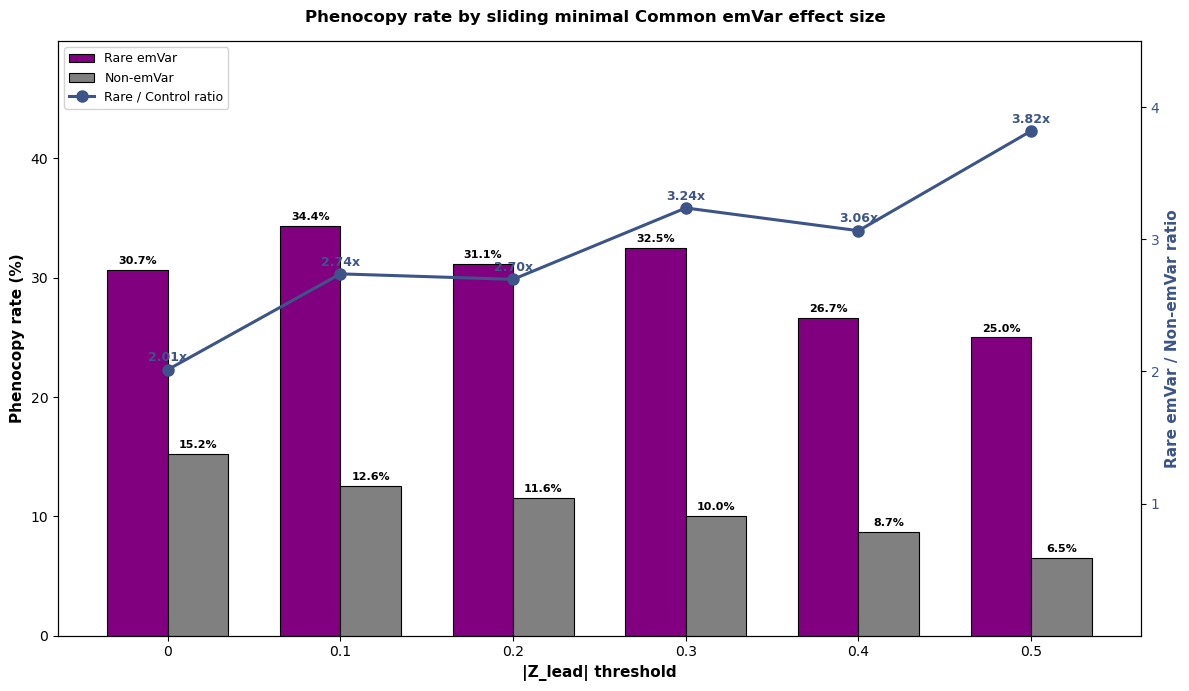

In [13]:
# ── Step 3.3  Sliding |Z_lead| stringency — window-level phenocopy rates ──
# For each Z_lead threshold, computes rare vs control phenocopy rates
# and their ratio. Plots grouped bars + ratio line.

%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

matplotlib.rcParams['pdf.fonttype']    = 42
matplotlib.rcParams['ps.fonttype']     = 42
matplotlib.rcParams['svg.fonttype']    = 'none'
matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Helvetica', 'Liberation Sans']

# ── Colors ─────────────────────────────────────────────────
C_LEAD  = '#83CEE1'
C_RARE  = 'purple'
C_CTRL  = 'grey'
C_RATIO = '#3C5488'

# ── 1. Compute phenocopy rates at each |Z_lead| threshold ─
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
results    = []

for thr in thresholds:
    rare_sub = df_rare[df_rare['Z_lead'].abs() >= thr]
    ctrl_sub = df_ctrl[df_ctrl['Z_lead'].abs() >= thr]
    n_r, n_c = len(rare_sub), len(ctrl_sub)
    results.append(dict(
        thr        = thr,
        n_rare     = n_r,
        n_ctrl     = n_c,
        rate_rare  = rare_sub['is_phenocopying'].sum() / n_r if n_r > 0 else np.nan,
        rate_ctrl  = ctrl_sub['is_phenocopying'].sum() / n_c if n_c > 0 else np.nan,
    ))

res = pd.DataFrame(results)

# Ratio only where both groups have >= 10 windows
ratio = np.where((res['n_rare'] >= 10) & (res['n_ctrl'] >= 10),
                 res['rate_rare'] / res['rate_ctrl'], np.nan)

# ── 2. Print table ─────────────────────────────────────────
print(f"\n{'='*75}")
print(f"  SLIDING |Z_lead| STRINGENCY -- Window-level Phenocopy Rates")
print(f"{'='*75}")
print(f"  {'|Z_lead|>=':>10}  {'Rare rate':>10} {'(n)':>7}  {'Ctrl rate':>10} {'(n)':>7}  {'Ratio':>7}")
print(f"  {'-'*73}")
for i, r in res.iterrows():
    ratio_str = f"{ratio[i]:.2f}x" if not np.isnan(ratio[i]) else "n/a"
    print(f"  {r.thr:>10.1f}  "
          f"{r.rate_rare*100:>9.1f}% {int(r.n_rare):>7,}  "
          f"{r.rate_ctrl*100:>9.1f}% {int(r.n_ctrl):>7,}  "
          f"{ratio_str:>7}")
print(f"{'='*75}")

# ── 3. Plot ────────────────────────────────────────────────
x           = np.arange(len(thresholds))
width       = 0.35
rare_rates  = res['rate_rare'].values * 100
ctrl_rates  = res['rate_ctrl'].values * 100
ymax_bar    = max(np.nanmax(rare_rates), np.nanmax(ctrl_rates))

fig, ax1 = plt.subplots(figsize=(12, 7))

# Grouped bars
b_rare = ax1.bar(x - width/2, rare_rates, width, color=C_RARE,
                 edgecolor='black', lw=0.8, zorder=3, label='Rare emVar')
b_ctrl = ax1.bar(x + width/2, ctrl_rates, width, color=C_CTRL,
                 edgecolor='black', lw=0.8, zorder=3, label='Non-emVar')

# Value labels on bars
for bars, rates in [(b_rare, rare_rates), (b_ctrl, ctrl_rates)]:
    for bar, rate in zip(bars, rates):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', va='bottom',
                 fontsize=8, fontweight='bold')

ax1.set_ylabel('Phenocopy rate (%)', fontsize=11, fontweight='bold')
ax1.set_ylim(0, ymax_bar * 1.45)
ax1.set_xticks(x)
ax1.set_xticklabels([str(t) for t in thresholds], fontsize=10)
ax1.set_xlabel('|Z_lead| threshold', fontsize=11, fontweight='bold')
ax1.grid(False)

# Ratio line on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, ratio, color=C_RATIO, marker='o', lw=2.2,
         markersize=8, zorder=5, label='Rare / Control ratio')
for xi, rv in zip(x, ratio):
    if not np.isnan(rv):
        ax2.text(xi, rv + 0.04, f'{rv:.2f}x', ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color=C_RATIO)

ax2.set_ylabel('Rare emVar / Non-emVar ratio', fontsize=11,
               fontweight='bold', color=C_RATIO)
ax2.tick_params(axis='y', labelcolor=C_RATIO)
ax2.set_ylim(0, 4.5)
ax2.set_yticks([1, 2, 3, 4])

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, framealpha=0.85, loc='upper left')

fig.suptitle('Phenocopy rate by sliding minimal Common emVar effect size',
             fontsize=12, fontweight='bold')
plt.tight_layout()

# with PdfPages('gtex_results/zlead_slide_barplot.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()
plt.close(fig)

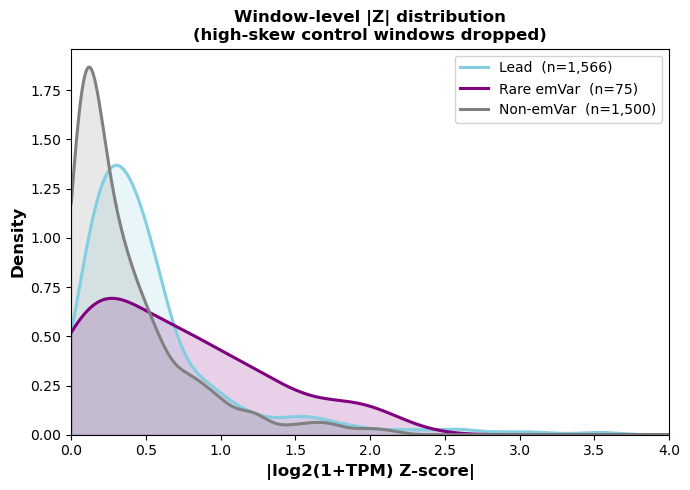


  KS TESTS (one-sided: alternative='less')
  Tests if first group is stochastically larger (shifted right)

  1. Rare vs Lead:
     n=75 vs n=1,578
     KS statistic : 0.2754
     p-value      : 1.3639e-05  *
     -> Rare is stochastically larger than Lead

  2. Rare vs Non-emVar:
     n=75 vs n=1,503
     KS statistic : 0.3424
     p-value      : 2.8175e-08  *
     -> Rare is stochastically larger than Non-emVar

  3. Lead vs Non-emVar:
     n=1,578 vs n=1,503
     KS statistic : 0.2610
     p-value      : 2.1586e-46  *
     -> Lead is stochastically larger than Non-emVar

  * significant at alpha = 0.05


/home/tx56/.conda/envs/2407/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


In [18]:
# ── Step 3.4  Absolute Z-score density + pairwise KS tests — window level ──
# KDE of |Z| for lead, rare, and control at the window level.
# Uses df_rare / df_ctrl from step 3.1 (high-skew windows already dropped).
# Pairwise one-sided KS tests for right-shift / tail-heaviness.

%matplotlib inline
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import gaussian_kde
from matplotlib.backends.backend_pdf import PdfPages

matplotlib.rcParams['pdf.fonttype']    = 42
matplotlib.rcParams['ps.fonttype']     = 42
matplotlib.rcParams['svg.fonttype']    = 'none'
matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Helvetica', 'Liberation Sans']

# ── Colors ─────────────────────────────────────────────────
C_LEAD = '#83CEE1'
C_RARE = 'purple'
C_CTRL = 'grey'

# ── 1. Collect absolute Z arrays ──────────────────────────
# Z_lead: union of rare + ctrl windows (both share the same lead z)
abs_lead = np.concatenate([df_rare['Z_lead'].abs().dropna().values,
                           df_ctrl['Z_lead'].abs().dropna().values])
abs_rare = df_rare['Z_rare'].abs().dropna().values
abs_ctrl = df_ctrl['Z_control'].abs().dropna().values

# ── 2. Clip and define KDE grid ───────────────────────────
XCUT = 4
def clip(arr): return arr[arr <= XCUT]

series = [
    (clip(abs_lead), C_LEAD, 'Lead'),
    (clip(abs_rare), C_RARE, 'Rare emVar'),
    (clip(abs_ctrl), C_CTRL, 'Non-emVar'),
]
zs = np.linspace(0, XCUT, 600)

# ── 3. Plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for vals, color, label in series:
    kde = gaussian_kde(vals, bw_method='scott')(zs)
    ax.fill_between(zs, 0, kde, color=color, alpha=0.18)
    ax.plot(zs, kde, color=color, lw=2.2, label=f"{label}  (n={len(vals):,})")

ax.set_xlim(0, XCUT)
ax.set_ylim(0, None)
ax.set_xlabel('|log2(1+TPM) Z-score|', fontsize=12, fontweight='bold')
ax.set_ylabel('Density',               fontsize=12, fontweight='bold')
ax.set_title('Window-level |Z| distribution\n(high-skew control windows dropped)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(False)
plt.tight_layout()

# os.makedirs('gtex_results', exist_ok=True)
# with PdfPages('gtex_results/abs_z_distribution.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()
plt.close(fig)

# ── 4. Pairwise one-sided KS tests ────────────────────────
# alternative='less': tests if first distribution is stochastically
# larger (shifted right) than the second
pairs = [
    (abs_rare, abs_lead, "Rare",    "Lead"),
    (abs_rare, abs_ctrl, "Rare",    "Non-emVar"),
    (abs_lead, abs_ctrl, "Lead",    "Non-emVar"),
]

print(f"\n{'='*70}")
print(f"  KS TESTS (one-sided: alternative='less')")
print(f"  Tests if first group is stochastically larger (shifted right)")
print(f"{'='*70}")

for i, (d1, d2, lab1, lab2) in enumerate(pairs, 1):
    ks_stat, p_val = stats.ks_2samp(d1, d2, alternative='less')
    sig = "*" if p_val < 0.05 else ""
    print(f"\n  {i}. {lab1} vs {lab2}:")
    print(f"     n={len(d1):,} vs n={len(d2):,}")
    print(f"     KS statistic : {ks_stat:.4f}")
    print(f"     p-value      : {p_val:.4e}  {sig}")
    result = (f"{lab1} is stochastically larger than {lab2}"
              if p_val < 0.05 else "No significant right-shift")
    print(f"     -> {result}")

print(f"\n{'='*70}")
print(f"  * significant at alpha = 0.05")
print(f"{'='*70}")

Loading TPM...
  TT (baseline) : n=407
  TC (lead-het) : n=229
  Rare emVar dots    : n=8

  Control rows: 99 → 96 (AF >= 0.01 filter)
  Rare Z values : 8  |  Control Z values : 96
  mean Z rare : -0.653  |  mean Z ctrl : 0.208
  Z_lead      : -0.096  |  p-value     : 0.01783

  Window: chr12_496721_T_C_b38 | Thyroid | sknsh
  Unique rare variants    : 1
  Unique control variants : 3


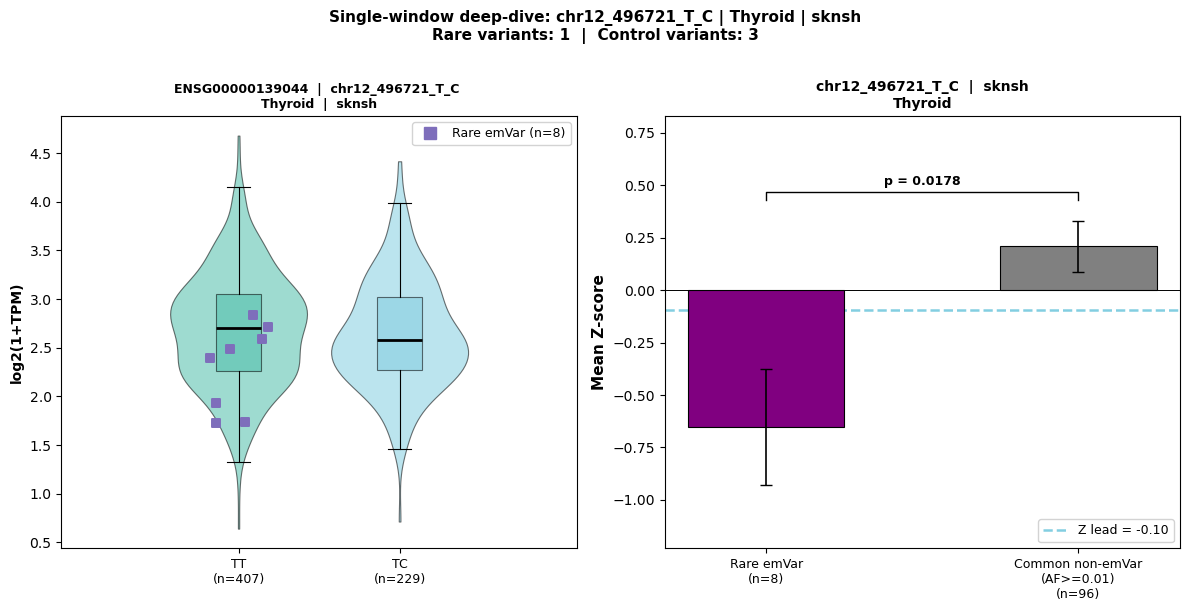

In [15]:
# ── Step 3.5  Single-window deep-dive: chr12_496721 / Thyroid / sknsh ──
# Violin: baseline (CC) vs lead-het (CT) with rare emVar dots overlaid
# Bar:    mean Z-score rare emVar vs common non-emVar (AF >= 0.01) + Welch t-test
# Counts: unique rare / control variants in the window

%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import ttest_ind

matplotlib.rcParams['pdf.fonttype']    = 42
matplotlib.rcParams['ps.fonttype']     = 42
matplotlib.rcParams['svg.fonttype']    = 'none'
matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Helvetica', 'Liberation Sans']

np.random.seed(42)

# ── Colors ─────────────────────────────────────────────────
C_MAJMAJ   = '#4EBEAB'
C_MAJMIN   = '#83CEE1'
C_LEAD     = '#83CEE1'
C_RARE_DOT = '#7E6EBB'
C_RARE_BAR = 'purple'
C_CTRL_BAR = 'grey'

# ── Target window ──────────────────────────────────────────
TARGET_LEAD   = "chr12_496721_T_C_b38"
TARGET_TISSUE = "Thyroid"
TARGET_CT     = "sknsh"
TARGET_GENE   = "ENSG00000139044.12"

_p     = TARGET_LEAD.split("_")
ref_al, alt_al = _p[2], _p[3]
lbl_mm = f"{ref_al}{ref_al}"
lbl_mM = f"{ref_al}{alt_al}"

# ══════════════════════════════════════════════════════════════
# 1. Load TPM + build violin data
# ══════════════════════════════════════════════════════════════
print("Loading TPM...")
tpm = pd.read_csv('variant_complete_tpm.csv')
if 'sample_name' not in tpm.columns and 'subject' in tpm.columns:
    tpm = tpm.rename(columns={'subject': 'sample_name'})
assert 'gt_class' in tpm.columns, "gt_class column missing!"

# Window rows from indiv (rare carrier subjects)
win_data  = indiv[
    (indiv['lead_variant_id_gtex'] == TARGET_LEAD) &
    (indiv['lead_tissue']          == TARGET_TISSUE) &
    (indiv['cell_type']            == TARGET_CT)
].copy()
rare_subjs = set(win_data[win_data['variant_tag'] == 'rare']['sample_name'].unique())

# TPM for this window
tpm_win = (tpm[
    (tpm['lead_variant_id_gtex'] == TARGET_LEAD) &
    (tpm['tissue']               == TARGET_TISSUE) &
    (tpm['cell_type']            == TARGET_CT)]
    .drop_duplicates(subset='sample_name')
    .dropna(subset=['tpm'])
    .copy())
tpm_win['log2tpm'] = np.log2(1 + tpm_win['tpm'])

grp_base = tpm_win[tpm_win['gt_class'] == 'CC']['log2tpm'].values
grp_lead = tpm_win[tpm_win['gt_class'] == 'CT']['log2tpm'].values
dot_rare  = tpm_win[tpm_win['sample_name'].isin(rare_subjs)].copy()

print(f"  {lbl_mm} (baseline) : n={len(grp_base)}")
print(f"  {lbl_mM} (lead-het) : n={len(grp_lead)}")
print(f"  Rare emVar dots    : n={len(dot_rare)}")

# ══════════════════════════════════════════════════════════════
# 2. Load match AF + build bar data
# ══════════════════════════════════════════════════════════════
match = (pd.read_csv('match_input_all.tsv', sep='\t', usecols=['variant_id', 'vcf_af'])
         .drop_duplicates(subset='variant_id'))
match['vcf_af'] = pd.to_numeric(match['vcf_af'], errors='coerce')

def gtex_to_colon(vid):
    return ':'.join(vid.replace('_b38', '').split('_'))

# Rare z-scores
z_rare = win_data[win_data['variant_tag'] == 'rare']['zscore'].dropna().values

# Control z-scores filtered to AF >= 0.01
ctrl_rows = win_data[win_data['variant_tag'] == 'control'].copy()
ctrl_rows['variant_id_colon'] = ctrl_rows['variant_id'].apply(gtex_to_colon)
ctrl_rows = ctrl_rows.merge(match[['variant_id', 'vcf_af']],
                             left_on='variant_id_colon', right_on='variant_id',
                             how='left')
n_before  = len(ctrl_rows)
ctrl_rows = ctrl_rows[pd.to_numeric(ctrl_rows['vcf_af'], errors='coerce') >= 0.01]
z_ctrl    = ctrl_rows['zscore'].dropna().values
print(f"\n  Control rows: {n_before} → {len(ctrl_rows)} (AF >= 0.01 filter)")
print(f"  Rare Z values : {len(z_rare)}  |  Control Z values : {len(z_ctrl)}")

# Z_lead from df_rare
win_row    = df_rare[(df_rare['lead_variant_id_gtex'] == TARGET_LEAD) &
                     (df_rare['lead_tissue']          == TARGET_TISSUE) &
                     (df_rare['cell_type']            == TARGET_CT)]
z_lead_val = win_row['Z_lead'].values[0]

# Stats
mean_rare = z_rare.mean();  sem_rare = z_rare.std(ddof=1) / np.sqrt(len(z_rare))
mean_ctrl = z_ctrl.mean();  sem_ctrl = z_ctrl.std(ddof=1) / np.sqrt(len(z_ctrl))
_, pval   = ttest_ind(z_rare, z_ctrl, equal_var=False)

print(f"  mean Z rare : {mean_rare:.3f}  |  mean Z ctrl : {mean_ctrl:.3f}")
print(f"  Z_lead      : {z_lead_val:.3f}  |  p-value     : {pval:.4g}")

# ══════════════════════════════════════════════════════════════
# 3. Variant counts
# ══════════════════════════════════════════════════════════════
variant_col = 'variant_id' if 'variant_id' in win_data.columns else 'variant'
n_rare_var  = win_data[win_data['variant_tag'] == 'rare'][variant_col].nunique()
n_ctrl_var  = win_data[win_data['variant_tag'] == 'control'][variant_col].nunique()

print(f"\n  Window: {TARGET_LEAD} | {TARGET_TISSUE} | {TARGET_CT}")
print(f"  Unique rare variants    : {n_rare_var}")
print(f"  Unique control variants : {n_ctrl_var}")

# ══════════════════════════════════════════════════════════════
# 4. Plot: violin (left) + bar (right)
# ══════════════════════════════════════════════════════════════
VIOLIN_GAP = 0.4
fig, (ax_v, ax_b) = plt.subplots(1, 2, figsize=(12, 6))
gene_short = TARGET_GENE.split(".")[0]

# ── Violin panel ───────────────────────────────────────────
positions     = [1 - VIOLIN_GAP/2, 1 + VIOLIN_GAP/2]
violin_data   = [grp_base, grp_lead]
violin_colors = [C_MAJMAJ, C_MAJMIN]

for pos, vals, color in zip(positions, violin_data, violin_colors):
    if len(vals) < 2: continue
    vp = ax_v.violinplot([vals], positions=[pos],
                          widths=VIOLIN_GAP * 0.85, showextrema=False)
    vp["bodies"][0].set_facecolor(color)
    vp["bodies"][0].set_alpha(0.55)
    vp["bodies"][0].set_edgecolor("black")
    vp["bodies"][0].set_linewidth(0.8)

    bp = ax_v.boxplot([vals], positions=[pos], widths=VIOLIN_GAP * 0.28,
                       patch_artist=True, showfliers=False, manage_ticks=False)
    bp["boxes"][0].set_facecolor(color);   bp["boxes"][0].set_alpha(0.55)
    bp["boxes"][0].set_edgecolor("black"); bp["boxes"][0].set_linewidth(0.8)
    bp["medians"][0].set_color("black");   bp["medians"][0].set_linewidth(2)
    for line in bp["whiskers"] + bp["caps"]:
        line.set_color("black"); line.set_linewidth(0.8)

# Rare emVar dots
for _, row in dot_rare.iterrows():
    x_pos = positions[0] if row['gt_class'] == 'CC' else positions[1]
    ax_v.scatter(x_pos + np.random.uniform(-0.08, 0.08), row['log2tpm'],
                 marker='s', facecolors=C_RARE_DOT, edgecolors=C_RARE_DOT,
                 s=32, lw=1.4, zorder=5, alpha=1.0)

ax_v.set_xticks(positions)
ax_v.set_xticklabels([f"{lbl_mm}\n(n={len(grp_base)})",
                       f"{lbl_mM}\n(n={len(grp_lead)})"], fontsize=9)
ax_v.set_ylabel("log2(1+TPM)", fontsize=10, fontweight='bold')
ax_v.set_xlim(1 - VIOLIN_GAP * 1.6, 1 + VIOLIN_GAP * 1.6)
ax_v.set_title(f"{gene_short}  |  {TARGET_LEAD.replace('_b38','')} \n"
               f"{TARGET_TISSUE}  |  {TARGET_CT}", fontsize=9, fontweight='bold')
ax_v.grid(False)
ax_v.legend(handles=[
    Line2D([0],[0], marker='s', color='w', markerfacecolor=C_RARE_DOT,
           markeredgecolor=C_RARE_DOT, markersize=8,
           label=f'Rare emVar (n={len(dot_rare)})')
], fontsize=9, loc='upper right', framealpha=0.85)

# ── Bar panel ──────────────────────────────────────────────
x      = np.array([0, 1])
means  = [mean_rare, mean_ctrl]
sems   = [sem_rare,  sem_ctrl]
labels = [f'Rare emVar\n(n={len(z_rare)})',
          f'Common non-emVar\n(AF>=0.01)\n(n={len(z_ctrl)})']

ax_b.bar(x, means, color=[C_RARE_BAR, C_CTRL_BAR],
         edgecolor='black', lw=0.8, width=0.5, zorder=3)
ax_b.errorbar(x, means, yerr=sems, fmt='none',
              color='black', capsize=4, lw=1.2, zorder=4)
ax_b.axhline(0,          color='black', lw=0.7, zorder=1)
ax_b.axhline(z_lead_val, color=C_LEAD,  lw=1.8, ls='--', zorder=2,
             label=f'Z lead = {z_lead_val:.2f}')

# p-value bracket
bar_tops  = [m + s for m, s in zip(means, sems)]
bar_bots  = [m - s for m, s in zip(means, sems)]
y_bracket = max(bar_tops) + 0.10
tick_len  = (max(bar_tops) - min(bar_bots)) * 0.03
ax_b.plot([0, 0, 1, 1],
          [y_bracket, y_bracket + tick_len, y_bracket + tick_len, y_bracket],
          color='black', lw=1.0)
p_str = f'p = {pval:.3g}' if pval >= 0.001 else 'p < 0.001'
ax_b.text(0.5, y_bracket + tick_len + 0.02, p_str,
          ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_b.set_xticks(x); ax_b.set_xticklabels(labels, fontsize=9)
ax_b.set_ylabel('Mean Z-score', fontsize=11, fontweight='bold')
ax_b.set_title(f'chr12_496721_T_C  |  {TARGET_CT}\n{TARGET_TISSUE}',
               fontsize=10, fontweight='bold')
ax_b.set_ylim(min(bar_bots) - 0.3, max(bar_tops) + 0.5)
ax_b.legend(fontsize=9, framealpha=0.85, loc='lower right')
ax_b.grid(False)

plt.suptitle(f"Single-window deep-dive: {TARGET_LEAD.replace('_b38','')} | "
             f"{TARGET_TISSUE} | {TARGET_CT}\n"
             f"Rare variants: {n_rare_var}  |  Control variants: {n_ctrl_var}",
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()

# os.makedirs('gtex_results', exist_ok=True)
# with PdfPages('gtex_results/violin_bar_chr12_sknsh.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()
plt.close(fig)

Loading TPM...
  CC (baseline) : n=512
  CT (lead-het) : n=152
  Rare emVar dots    : n=4

  Control rows: 22 -> 12 (AF >= 0.01 filter)
  Rare Z values : 4  |  Control Z values : 12
  mean Z rare : -0.387  |  mean Z ctrl : -0.344
  Z_lead      : -0.197  |  p-value     : 0.9318

  Window : chr3_15293390_C_T_b38 | Artery_Tibial | k562
  Unique rare variants    : 1
  Unique control variants : 4


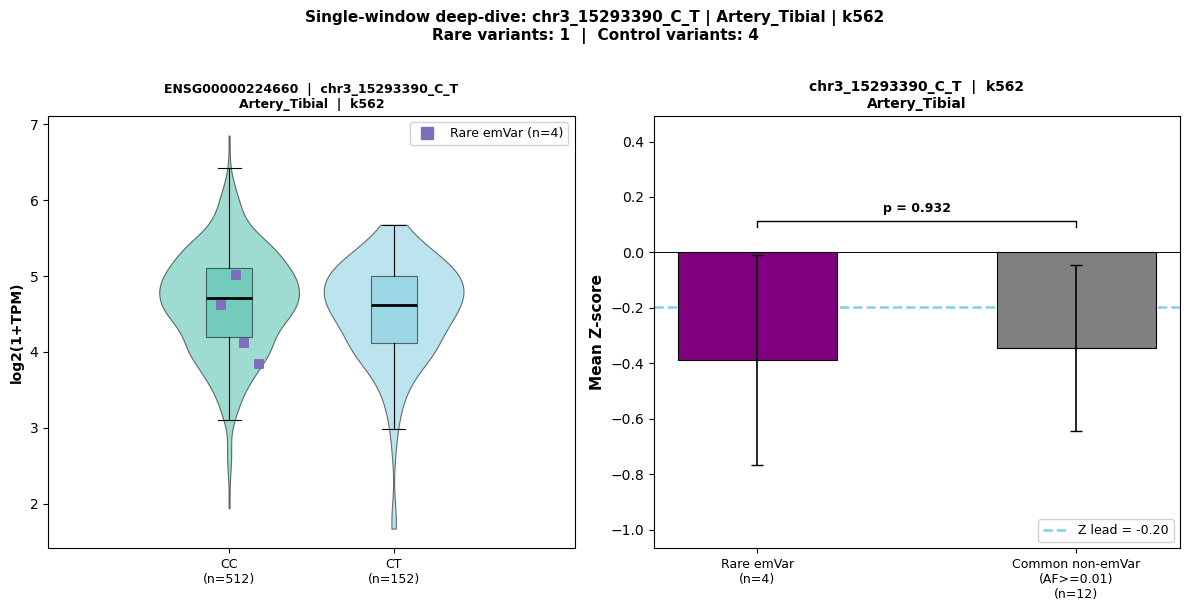

In [16]:
# ── Step 3.6  Single-window deep-dive: chr3_15293390 / Artery_Tibial / k562 ──
# Same structure as step 3.5 but for chr3 / k562 window.
# Violin: baseline (CC) vs lead-het (CT) with rare emVar dots overlaid
# Bar:    mean Z-score rare emVar vs common non-emVar (AF >= 0.01) + Welch t-test
# Counts: unique rare / control variants in the window

%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import ttest_ind

matplotlib.rcParams['pdf.fonttype']    = 42
matplotlib.rcParams['ps.fonttype']     = 42
matplotlib.rcParams['svg.fonttype']    = 'none'
matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Helvetica', 'Liberation Sans']

np.random.seed(42)

# ── Colors ─────────────────────────────────────────────────
C_MAJMAJ   = '#4EBEAB'
C_MAJMIN   = '#83CEE1'
C_LEAD     = '#83CEE1'
C_RARE_DOT = '#7E6EBB'
C_RARE_BAR = 'purple'
C_CTRL_BAR = 'grey'

# ── Target window ──────────────────────────────────────────
TARGET_LEAD   = "chr3_15293390_C_T_b38"
TARGET_TISSUE = "Artery_Tibial"
TARGET_CT     = "k562"
TARGET_GENE   = "ENSG00000224660.2"

_p             = TARGET_LEAD.split("_")
ref_al, alt_al = _p[2], _p[3]
lbl_mm         = f"{ref_al}{ref_al}"
lbl_mM         = f"{ref_al}{alt_al}"
gene_short     = TARGET_GENE.split(".")[0]

# ── Output path (derived, not hard-coded) ─────────────────
_chr  = TARGET_LEAD.split("_")[0]
_cell = TARGET_CT.replace("/", "_")
OUT_PDF = os.path.join("gtex_results", f"violin_bar_{_chr}_{_cell}.pdf")

# ══════════════════════════════════════════════════════════════
# 1. Load TPM + build violin data
# ══════════════════════════════════════════════════════════════
print("Loading TPM...")
tpm = pd.read_csv('variant_complete_tpm.csv')
if 'sample_name' not in tpm.columns and 'subject' in tpm.columns:
    tpm = tpm.rename(columns={'subject': 'sample_name'})
assert 'gt_class' in tpm.columns, "gt_class column missing!"

win_data = indiv[
    (indiv['lead_variant_id_gtex'] == TARGET_LEAD) &
    (indiv['lead_tissue']          == TARGET_TISSUE) &
    (indiv['cell_type']            == TARGET_CT)
].copy()
rare_subjs = set(win_data[win_data['variant_tag'] == 'rare']['sample_name'].unique())

tpm_win = (tpm[
    (tpm['lead_variant_id_gtex'] == TARGET_LEAD) &
    (tpm['tissue']               == TARGET_TISSUE) &
    (tpm['cell_type']            == TARGET_CT)]
    .drop_duplicates(subset='sample_name')
    .dropna(subset=['tpm'])
    .copy())
tpm_win['log2tpm'] = np.log2(1 + tpm_win['tpm'])

grp_base = tpm_win[tpm_win['gt_class'] == 'CC']['log2tpm'].values
grp_lead = tpm_win[tpm_win['gt_class'] == 'CT']['log2tpm'].values
dot_rare  = tpm_win[tpm_win['sample_name'].isin(rare_subjs)].copy()

print(f"  {lbl_mm} (baseline) : n={len(grp_base)}")
print(f"  {lbl_mM} (lead-het) : n={len(grp_lead)}")
print(f"  Rare emVar dots    : n={len(dot_rare)}")

# ══════════════════════════════════════════════════════════════
# 2. Load match AF + build bar data
# ══════════════════════════════════════════════════════════════
match = (pd.read_csv('match_input_all.tsv', sep='\t', usecols=['variant_id', 'vcf_af'])
         .drop_duplicates(subset='variant_id'))
match['vcf_af'] = pd.to_numeric(match['vcf_af'], errors='coerce')

def gtex_to_colon(vid):
    return ':'.join(str(vid).replace('_b38', '').split('_'))

z_rare    = win_data[win_data['variant_tag'] == 'rare']['zscore'].dropna().values
ctrl_rows = win_data[win_data['variant_tag'] == 'control'].copy()
ctrl_rows['variant_id_colon'] = ctrl_rows['variant_id'].apply(gtex_to_colon)
ctrl_rows = ctrl_rows.merge(match[['variant_id', 'vcf_af']],
                             left_on='variant_id_colon', right_on='variant_id',
                             how='left')
n_before  = len(ctrl_rows)
ctrl_rows = ctrl_rows[pd.to_numeric(ctrl_rows['vcf_af'], errors='coerce') >= 0.01]
z_ctrl    = ctrl_rows['zscore'].dropna().values

print(f"\n  Control rows: {n_before} -> {len(ctrl_rows)} (AF >= 0.01 filter)")
print(f"  Rare Z values : {len(z_rare)}  |  Control Z values : {len(z_ctrl)}")

# Z_lead from df_rare (step 3.1)
win_row = df_rare[
    (df_rare['lead_variant_id_gtex'] == TARGET_LEAD) &
    (df_rare['lead_tissue']          == TARGET_TISSUE) &
    (df_rare['cell_type']            == TARGET_CT)
]
if len(win_row) == 0:
    raise ValueError("Window not found in df_rare — check TARGET_* values")
z_lead_val = win_row['Z_lead'].values[0]

mean_rare = z_rare.mean() if len(z_rare) else np.nan
mean_ctrl = z_ctrl.mean() if len(z_ctrl) else np.nan
sem_rare  = z_rare.std(ddof=1) / np.sqrt(len(z_rare)) if len(z_rare) > 1 else 0
sem_ctrl  = z_ctrl.std(ddof=1) / np.sqrt(len(z_ctrl)) if len(z_ctrl) > 1 else 0
_, pval   = ttest_ind(z_rare, z_ctrl, equal_var=False) if (len(z_rare) > 1 and len(z_ctrl) > 1) else (None, np.nan)

print(f"  mean Z rare : {mean_rare:.3f}  |  mean Z ctrl : {mean_ctrl:.3f}")
print(f"  Z_lead      : {z_lead_val:.3f}  |  p-value     : {pval:.4g}")

# ══════════════════════════════════════════════════════════════
# 3. Variant counts
# ══════════════════════════════════════════════════════════════
variant_col = 'variant_id' if 'variant_id' in win_data.columns else 'variant'
n_rare_var  = win_data[win_data['variant_tag'] == 'rare'][variant_col].nunique()
n_ctrl_var  = win_data[win_data['variant_tag'] == 'control'][variant_col].nunique()

print(f"\n  Window : {TARGET_LEAD} | {TARGET_TISSUE} | {TARGET_CT}")
print(f"  Unique rare variants    : {n_rare_var}")
print(f"  Unique control variants : {n_ctrl_var}")

# ══════════════════════════════════════════════════════════════
# 4. Plot: violin (left) + bar (right)
# ══════════════════════════════════════════════════════════════
VIOLIN_GAP = 0.4
fig, (ax_v, ax_b) = plt.subplots(1, 2, figsize=(12, 6))

# ── Violin panel ───────────────────────────────────────────
positions     = [1 - VIOLIN_GAP/2, 1 + VIOLIN_GAP/2]
violin_data   = [grp_base, grp_lead]
violin_colors = [C_MAJMAJ, C_MAJMIN]

for pos, vals, color in zip(positions, violin_data, violin_colors):
    if len(vals) < 2: continue
    vp = ax_v.violinplot([vals], positions=[pos],
                          widths=VIOLIN_GAP * 0.85, showextrema=False)
    vp["bodies"][0].set_facecolor(color)
    vp["bodies"][0].set_alpha(0.55)
    vp["bodies"][0].set_edgecolor("black")
    vp["bodies"][0].set_linewidth(0.8)

    bp = ax_v.boxplot([vals], positions=[pos], widths=VIOLIN_GAP * 0.28,
                       patch_artist=True, showfliers=False, manage_ticks=False)
    bp["boxes"][0].set_facecolor(color);   bp["boxes"][0].set_alpha(0.55)
    bp["boxes"][0].set_edgecolor("black"); bp["boxes"][0].set_linewidth(0.8)
    bp["medians"][0].set_color("black");   bp["medians"][0].set_linewidth(2)
    for line in bp["whiskers"] + bp["caps"]:
        line.set_color("black"); line.set_linewidth(0.8)

for _, row in dot_rare.iterrows():
    x_pos = positions[0] if row['gt_class'] == 'CC' else positions[1]
    ax_v.scatter(x_pos + np.random.uniform(-0.08, 0.08), row['log2tpm'],
                 marker='s', facecolors=C_RARE_DOT, edgecolors=C_RARE_DOT,
                 s=32, lw=1.4, zorder=5, alpha=1.0)

ax_v.set_xticks(positions)
ax_v.set_xticklabels([f"{lbl_mm}\n(n={len(grp_base)})",
                       f"{lbl_mM}\n(n={len(grp_lead)})"], fontsize=9)
ax_v.set_ylabel("log2(1+TPM)", fontsize=10, fontweight='bold')
ax_v.set_xlim(1 - VIOLIN_GAP * 1.6, 1 + VIOLIN_GAP * 1.6)
ax_v.set_title(f"{gene_short}  |  {TARGET_LEAD.replace('_b38','')}\n"
               f"{TARGET_TISSUE}  |  {TARGET_CT}", fontsize=9, fontweight='bold')
ax_v.grid(False)
ax_v.legend(handles=[
    Line2D([0],[0], marker='s', color='w', markerfacecolor=C_RARE_DOT,
           markeredgecolor=C_RARE_DOT, markersize=8,
           label=f'Rare emVar (n={len(dot_rare)})')
], fontsize=9, loc='upper right', framealpha=0.85)

# ── Bar panel ──────────────────────────────────────────────
x      = np.array([0, 1])
means  = [mean_rare, mean_ctrl]
sems   = [sem_rare,  sem_ctrl]
labels = [f'Rare emVar\n(n={len(z_rare)})',
          f'Common non-emVar\n(AF>=0.01)\n(n={len(z_ctrl)})']

ax_b.bar(x, means, color=[C_RARE_BAR, C_CTRL_BAR],
         edgecolor='black', lw=0.8, width=0.5, zorder=3)
ax_b.errorbar(x, means, yerr=sems, fmt='none',
              color='black', capsize=4, lw=1.2, zorder=4)
ax_b.axhline(0,          color='black', lw=0.7, zorder=1)
ax_b.axhline(z_lead_val, color=C_LEAD,  lw=1.8, ls='--', zorder=2,
             label=f'Z lead = {z_lead_val:.2f}')

bar_tops  = [m + s for m, s in zip(means, sems)]
bar_bots  = [m - s for m, s in zip(means, sems)]
y_bracket = max(bar_tops) + 0.10
span      = max(bar_tops) - min(bar_bots)
tick_len  = span * 0.03 if span != 0 else 0.05
ax_b.plot([0, 0, 1, 1],
          [y_bracket, y_bracket + tick_len, y_bracket + tick_len, y_bracket],
          color='black', lw=1.0)
p_str = f'p = {pval:.3g}' if (not np.isnan(pval) and pval >= 0.001) else 'p < 0.001'
ax_b.text(0.5, y_bracket + tick_len + 0.02, p_str,
          ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_b.set_xticks(x); ax_b.set_xticklabels(labels, fontsize=9)
ax_b.set_ylabel('Mean Z-score', fontsize=11, fontweight='bold')
ax_b.set_title(f'{TARGET_LEAD.replace("_b38","")}  |  {TARGET_CT}\n{TARGET_TISSUE}',
               fontsize=10, fontweight='bold')
ax_b.set_ylim(min(bar_bots) - 0.3, max(bar_tops) + 0.5)
ax_b.legend(fontsize=9, framealpha=0.85, loc='lower right')
ax_b.grid(False)

plt.suptitle(f"Single-window deep-dive: {TARGET_LEAD.replace('_b38','')} | "
             f"{TARGET_TISSUE} | {TARGET_CT}\n"
             f"Rare variants: {n_rare_var}  |  Control variants: {n_ctrl_var}",
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()

# os.makedirs('gtex_results', exist_ok=True)
# with PdfPages(OUT_PDF) as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()
plt.close(fig)

  bcftools : /home/tx56/.conda/envs/2407/bin/bcftools
  VCF subjects : 953

  chr1_78053255_A_G_b38 | Spleen | ENSG00000137960
    TPM entries : 19,616  | gene_name: GIPC2
    hom_ref: 182  het: 85

  chr9_127562120_G_A_b38 | Cells_Cultured_fibroblasts | ENSG00000136830
    TPM entries : 19,616  | gene_name: NIBAN2
    hom_ref: 594  het: 54

  2 windows cached


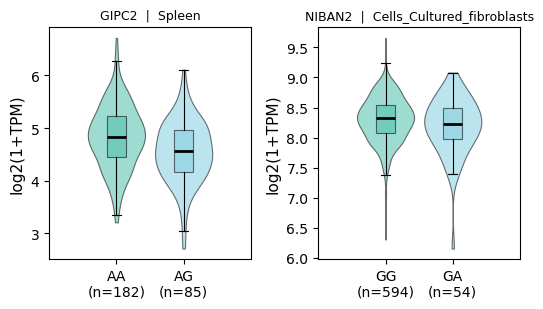

In [17]:
# ── eQTL violin: extract genotype + TPM from GCT/VCF, plot per window ──
# Cell 1: extracts data into plot_cache (no plotting)
# Cell 2: plots from cache, PDF save commented out

%matplotlib inline
import os, gzip, subprocess, shutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

matplotlib.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',
    'font.family': 'DejaVu Sans'
})

# ── Paths ──────────────────────────────────────────────────
BASE_DIR    = "/vast/palmer/scratch/reilly/tx56/recoded_gtex/final_shadow_variant_altBG_and_noAF_filter"
MPAC_DIR    = "/home/tx56/palmer_scratch/mpac_20250426"
GTEX_LINKER = os.path.join(BASE_DIR, "gtex_sample_linker.tsv")
TPM_GCT     = os.path.join(MPAC_DIR, "dbgap_rna_seq/GTEx_Analysis_v10_RNASeQCv2.4.2_gene_tpm.gct.gz")
VCF_PATH    = os.path.join(MPAC_DIR, "dbgap_wgs_copy/phg001796.v1.GTEx_v9_WGS_phased.genotype-calls-vcf.c1/GTEx_Analysis_2021-02-11_v9_WholeGenomeSeq_953Indiv.SHAPEIT2_phased.vcf.gz")

# ── Colors ─────────────────────────────────────────────────
C_BASELINE, C_LEAD = '#4EBEAB', '#83CEE1'

# ── Target windows ─────────────────────────────────────────
TARGET_WINDOWS = [
    {"lead_variant_id_gtex": "chr1_78053255_A_G_b38",
     "lead_tissue": "Spleen",          "gene_id": "ENSG00000137960.6"},
    {"lead_variant_id_gtex": "chr9_127562120_G_A_b38",
     "lead_tissue": "Cells_Cultured_Fibroblasts", "gene_id": "ENSG00000136830.12"},
]

# ── bcftools ───────────────────────────────────────────────
HOME = os.path.expanduser("~")
bcftools = next(
    (p for p in [shutil.which("bcftools"),
                 os.path.join(HOME, ".conda/envs/2407/bin/bcftools"),
                 "/usr/bin/bcftools", "/usr/local/bin/bcftools"]
     if p and os.path.isfile(p)), None)
if not bcftools: raise EnvironmentError("bcftools not found")
print(f"  bcftools : {bcftools}")

# ── Sample linker ──────────────────────────────────────────
df_link = pd.read_csv(GTEX_LINKER, sep="\t", low_memory=False)
linker  = {}
for _, r in df_link.iterrows():
    linker.setdefault((r["subject"], r["meta_tissue"]), []).append(r["sample_id"])

all_tissues = sorted(set(k[1] for k in linker.keys()))

def resolve_tissue(req):
    if req in all_tissues: return req
    lmap = {t.lower(): t for t in all_tissues}
    if req.lower() in lmap: return lmap[req.lower()]
    parts = [t for t in all_tissues if req.lower() in t.lower()]
    if parts: return parts[0]
    return None

# ── VCF subjects ───────────────────────────────────────────
vcf_samples = subprocess.run([bcftools, "query", "-l", VCF_PATH],
                              capture_output=True, text=True).stdout.strip().split("\n")
subjects = ["-".join(s.split("-")[:2]) for s in vcf_samples]
print(f"  VCF subjects : {len(subjects):,}")

# ══════════════════════════════════════════════════════════
# CELL 1 — Data extraction into plot_cache
# ══════════════════════════════════════════════════════════
plot_cache = []
all_sids   = set(sid for sids in linker.values() for sid in sids)

for tw in TARGET_WINDOWS:
    lv, tis_raw, gene_id = tw["lead_variant_id_gtex"], tw["lead_tissue"], tw["gene_id"]
    gene_short = gene_id.split(".")[0]
    ref_al, alt_al = lv.split("_")[2], lv.split("_")[3]

    tis = resolve_tissue(tis_raw)
    if tis is None:
        print(f"  Skipping {lv} — tissue '{tis_raw}' not found"); continue

    print(f"\n  {lv} | {tis} | {gene_short}")

    # ── TPM from GCT ──────────────────────────────────────
    tpm_lookup, gene_name = {}, gene_short
    with gzip.open(TPM_GCT, "rt") as f:
        next(f); next(f)
        header  = next(f).rstrip("\n").split("\t")
        col_idx = [i for i, h in enumerate(header) if h in all_sids]
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if parts[0].split(".")[0] != gene_short: continue
            gene_name = parts[1] if len(parts) > 1 and parts[1] not in ("", "NA") else gene_short
            for i in col_idx:
                tpm_lookup[(gene_short, header[i])] = float(parts[i])
            break
    print(f"    TPM entries : {len(tpm_lookup):,}  | gene_name: {gene_name}")

    # ── Genotypes from VCF ────────────────────────────────
    chrom, pos = lv.split("_")[0], lv.split("_")[1]
    rows, proc = [], subprocess.Popen(
        [bcftools, "query", "-r", f"{chrom}:{pos}-{pos}",
         "-f", "%CHROM\t%POS\t%REF\t%ALT[\t%GT]\n", VCF_PATH],
        stdout=subprocess.PIPE, text=True)
    for line in proc.stdout:
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 5: continue
        for i, gt_raw in enumerate(fields[4:]):
            gt_str = gt_raw.split(":")[0].replace("|", "/")
            if "." in gt_str: continue
            try: n_alt = sum(int(a) for a in gt_str.split("/"))
            except: continue
            if n_alt == 2: continue
            subj = subjects[i]
            tpm_val = next(
                (tpm_lookup[(gene_short, sid)]
                 for sid in linker.get((subj, tis), [])
                 if (gene_short, sid) in tpm_lookup), np.nan)
            rows.append({"subject": subj,
                         "gt_class": "hom_ref" if n_alt == 0 else "het",
                         "tpm": tpm_val})
    proc.wait()

    df_gt = pd.DataFrame(rows).dropna(subset=["tpm"])
    df_gt["log2tpm"] = np.log2(1 + df_gt["tpm"])
    print(f"    hom_ref: {(df_gt['gt_class']=='hom_ref').sum():,}  "
          f"het: {(df_gt['gt_class']=='het').sum():,}")

    plot_cache.append(dict(lv=lv, tis=tis, gene_name=gene_name,
                           gene_short=gene_short, ref_al=ref_al, alt_al=alt_al,
                           df_gt=df_gt.copy()))

print(f"\n  {len(plot_cache)} windows cached")

# ══════════════════════════════════════════════════════════
# CELL 2 — Plot from cache
# ══════════════════════════════════════════════════════════
VIOLIN_GAP = 0.4

fig, axes = plt.subplots(1, len(plot_cache), figsize=(2.7 * len(plot_cache), 3.2))
if len(plot_cache) == 1: axes = [axes]

for ax, entry in zip(axes, plot_cache):
    df_gt    = entry["df_gt"]
    ref_al   = entry["ref_al"]
    alt_al   = entry["alt_al"]
    gt_groups = [("hom_ref", f"{ref_al}{ref_al}", C_BASELINE),
                 ("het",     f"{ref_al}{alt_al}", C_LEAD)]
    positions = [1 - VIOLIN_GAP/2, 1 + VIOLIN_GAP/2]

    for pos, (gt_class, label, color) in zip(positions, gt_groups):
        vals = df_gt[df_gt["gt_class"] == gt_class]["log2tpm"].values
        if len(vals) < 2: continue

        vp = ax.violinplot([vals], positions=[pos],
                           widths=VIOLIN_GAP * 0.85, showextrema=False)
        vp["bodies"][0].set_facecolor(color)
        vp["bodies"][0].set_alpha(0.55)
        vp["bodies"][0].set_edgecolor("black")
        vp["bodies"][0].set_linewidth(0.8)

        bp = ax.boxplot([vals], positions=[pos], widths=VIOLIN_GAP * 0.28,
                        patch_artist=True, showfliers=False, manage_ticks=False)
        bp["boxes"][0].set_facecolor(color);    bp["boxes"][0].set_alpha(0.55)
        bp["boxes"][0].set_edgecolor("black");  bp["boxes"][0].set_linewidth(0.8)
        bp["medians"][0].set_color("black");    bp["medians"][0].set_linewidth(2)
        for line in bp["whiskers"] + bp["caps"]:
            line.set_color("black"); line.set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [f"{g[1]}\n(n={len(df_gt[df_gt['gt_class']==g[0]]):,})"
         for g in gt_groups], fontsize=10)
    ax.set_ylabel("log2(1+TPM)", fontsize=11)
    ax.set_title(f"{entry['gene_name']}  |  {entry['tis']}", fontsize=9)
    ax.set_xlim(1 - VIOLIN_GAP * 1.5, 1 + VIOLIN_GAP * 1.5)
    ax.grid(False)

plt.tight_layout()

# os.makedirs("gtex_results", exist_ok=True)
# with PdfPages("gtex_results/eqtl_2_examples.pdf") as pdf:
#     for fig_ in [fig]: pdf.savefig(fig_, bbox_inches='tight')

plt.show()
plt.close(fig)